## Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import random
from itertools import combinations
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# For experiment analysis (keeping parallel to andrew's baseline)
import itertools
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

import exp as exptb

# For trying class balancing
from imblearn.over_sampling import SMOTE

# For counterfactual/recourse analysis
import dice_ml
import recourse_metrics
from raiutils.exceptions import UserConfigValidationException
import json
import ast
import re
from pathlib import Path

from multi_adversarial_debiasing import (
    MultiAdversarialMLP,
    evaluate_multi_adversarial_model,
    make_adversarial_loaders,
    prepare_smote_case_with_sensitive_labels,
    add_intersection_protected_target,
    train_multi_adversarial_model,
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# "label" for comparability and comparability with andrew's encoded pipeline.
ENCODING_MODE = "label"   # onehot for future upgrade.
BATCH_SIZE = 512
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6


## Dataset Analysis & Preprocessing


In [3]:
# Load and begin prepping strip search data
df = pd.read_csv('./datasets/torontostripsearch.csv', delimiter=',');
df.head()

,Arrest_Year,Arrest_Month,EventID,ArrestID,PersonID,Perceived_Race,Sex,Age_group__at_arrest_,Youth_at_arrest__under_18_years,ArrestLocDiv,...,Actions_at_arrest___Resisted__d,Actions_at_arrest___Mental_inst,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative,SearchReason_CauseInjury,SearchReason_AssistEscape,SearchReason_PossessWeapons,SearchReason_PossessEvidence,ItemsFound,ObjectId
0,2020,July-Sept,1005907,6017884.0,326622,White,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,1,NaN,NaN,NaN,NaN,NaN,1
1,2020,July-Sept,1014562,6056669.0,326622,White,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,2
2,2020,Oct-Dec,1029922,6057065.0,326622,Unknown or Legacy,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,3
3,2021,Jan-Mar,1052190,6029059.0,327535,Black,M,Aged 25 to 34 years,Not a youth,XX,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,4
4,2021,Jan-Mar,1015512,6040372.0,327535,South Asian,M,Aged 25 to 34 years,Not a youth,XX,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,5


In [4]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}") #list unique valuyes for each column to get a sense of the data.
    print(df[col].unique())

Arrest_Year: 2
[2020 2021]
Arrest_Month: 4
['July-Sept' 'Oct-Dec' 'Jan-Mar' 'Apr-June']
EventID: 60003
[1005907 1014562 1029922 ... 1021067 1008998 1033395]
ArrestID: 64805
[6017884. 6056669. 6057065. ... 6064396. 6008662. 6032145.]
PersonID: 37347
[326622 327535 330778 ... 324057 331870 310583]
Perceived_Race: 8
['White' 'Unknown or Legacy' 'Black' 'South Asian' 'Indigenous'
 'Middle-Eastern' 'Latino' 'East/Southeast Asian' nan]
Sex: 3
['M' 'F' 'U']
Age_group__at_arrest_: 9
['Aged 35 to 44 years' 'Aged 25 to 34 years' 'Aged 45 to 54 years'
 'Aged 55 to 64 years' 'Aged 18 to 24 years' 'Aged 65 and older'
 'Aged 65 years and older' nan 'Aged 17 years and younger'
 'Aged 17 years and under']
Youth_at_arrest__under_18_years: 3
['Not a youth' 'Youth (aged 17 and younger)'
 'Youth (aged 17 years and under)']
ArrestLocDiv: 18
['54' 'XX' '42' '52' '14' '51' '53' '31' '11' '12' '13' '41' '22' '55'
 '43' '23' '33' '32']
StripSearch: 2
[0 1]
Booked: 2
[1 0]
Occurrence_Category: 31
['Assault & Ot

In [5]:

df['IsYouth'] = np.where(df['Youth_at_arrest__under_18_years'] == "Not a youth", 0, 1)
df = df.rename(columns={"Arrest_Month" : "Arrest_Quarter"})
df.drop(columns=df.columns.intersection(['SearchReason_CauseInjury', 'SearchReason_AssistEscape', 'SearchReason_PossessWeapons', 'Arrest_Year',
                                         'SearchReason_PossessEvidence', 'Youth_at_arrest__under_18_years', "_defensive_or_escape_risk",
                                         'ObjectId', 'EventID', 'ArrestID', 'PersonID', 'Booked', 'ItemsFound']), axis=1, inplace=True)

df.replace({'Perceived_Race': {np.nan: 'Unknown or Legacy'}}, inplace=True)

df = df.drop(df[df['Sex'] == 'U'].index)

df.dropna(how="any", inplace=True)
categorical_features = ['Perceived_Race', 'Sex', 'Occurrence_Category', 'ArrestLocDiv']
ordinal_features = ['Age_group__at_arrest_', 'Arrest_Quarter']
binary_features = ['IsYouth','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']


X = df.drop('StripSearch', axis=1)
X = X.drop('IsYouth', axis=1) # keep IsYouth and change how it affects the model in future work
y = df['StripSearch']

# Map the age groups to the specified values
custom_mapping = {
    'Aged 17 years and under': 0,
    'Aged 17 years and younger': 0,
    'Aged 18 to 24 years': 1,
    'Aged 25 to 34 years': 2,
    'Aged 35 to 44 years': 3,
    'Aged 45 to 54 years': 4,
    'Aged 55 to 64 years': 5,
    'Aged 65 and older': 6,
    'Aged 65 years and older': 6
}

quarter_mapping = {
"Jan-Mar" : 0,
"Apr-June" : 1,
"July-Sept" : 3,
"Oct-Dec" : 4
}

X['Age_group__at_arrest_'] = X['Age_group__at_arrest_'].map(custom_mapping)
X['Arrest_Quarter'] = X['Arrest_Quarter'].map(quarter_mapping)

# Store the reverse mappings for later use in analysis and visualization
rev_custom_mapping = {
    0 : 'Aged 17 years and younger',
    1 : 'Aged 18 to 24 years'      ,
    2 : 'Aged 25 to 34 years'      ,
    3 : 'Aged 35 to 44 years'      ,
    4 : 'Aged 45 to 54 years'      ,
    5 : 'Aged 55 to 64 years'      ,
    6 : 'Aged 65 and older'        
}

rev_quarter_mapping = {
    0 : "Jan-Mar"   ,
    1 : "Apr-June"  ,
    3 : "July-Sept" ,
    4 : "Oct-Dec"   
}

custom_encoders = {
    'Age_group__at_arrest_': rev_custom_mapping,
    'Arrest_Quarter': rev_quarter_mapping
}

In [6]:
# train/test split (same as Andrew)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build analysis copies with label encoding so slicing/explanation-table code still works
X_train_analysis = X_train.copy()
X_test_analysis = X_test.copy()

#Analysing which encoders we require for our Dataset and NN baseline
# 1. We have 4 categorical features: Perceived_Race, Sex, Occurrence_Category, ArrestLocDiv
# 2. We have 2 ordinal features: Age_group__at_arrest_, Arrest
# 3. We have 7 binary features: IsYouth, Actions_at_arrest___Concealed_i, Actions_at_arrest___Combative__, Actions_at_arrest___Resisted__d, Actions_at_arrest___Mental_inst, Actions_at_arrest___Assaulted_o, Actions_at_arrest___Cooperative

# Output directories for NN baseline artifacts
import os
OUT_BASE_DIR = "nn_madb_outputs"
ENCODER_DIR = os.path.join(OUT_BASE_DIR, "encoder_tables")
FP_DIR = os.path.join(OUT_BASE_DIR, "fp_analysis")
DICE_DIR = os.path.join(OUT_BASE_DIR, "dice_cf")
RECOURSE_TEMP_DIR = os.path.join(OUT_BASE_DIR, "recourse_temp")
RECOURSE_TABLE_DIR = os.path.join(OUT_BASE_DIR, "recourse_tables")
for _d in [ENCODER_DIR, FP_DIR, DICE_DIR, RECOURSE_TEMP_DIR, RECOURSE_TABLE_DIR]:
    os.makedirs(_d, exist_ok=True)
print("Output dirs ready under:", OUT_BASE_DIR)

Output dirs ready under: nn_madb_outputs


## Encoder + SMOTE
After multiple ablations where we applied different sets of encoding techniques, we landed on the on the below combination as it gave the best utility-fairness balance. 
- categorical features (one-hot), ordinal features (ordinal encoder), binary features (one-hot )


In [7]:
# Base split copies
X_train_base = X_train.copy(deep=True)
X_test_base = X_test.copy(deep=True)

# Labels once (shared across all cases)
y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)


def build_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_ord():
    return OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Keep only columns that are actually present in model frame (e.g., IsYouth may be dropped upstream)
cat_cols = [c for c in categorical_features if c in X_train_base.columns]
ord_cols = [c for c in ordinal_features if c in X_train_base.columns]
bin_cols = [c for c in binary_features if c in X_train_base.columns]

missing_cat = sorted(set(categorical_features) - set(cat_cols))
missing_ord = sorted(set(ordinal_features) - set(ord_cols))
missing_bin = sorted(set(binary_features) - set(bin_cols))

if missing_cat or missing_ord or missing_bin:
    print(" Skipped missing columns ->")
    print("  categorical:", missing_cat)
    print("  ordinal:", missing_ord)
    print("  binary:", missing_bin)

def run_case(case_name, preprocessor, Xtr, Xte, y_train_np, y_test_np, smote=False, random_state=42):
    
        
    Xtr_enc = preprocessor.fit_transform(Xtr)
    Xte_enc = preprocessor.transform(Xte)

    if smote:
        smote_sampler = SMOTE(random_state=random_state)
        Xtr_enc, y_train_np = smote_sampler.fit_resample(X=Xtr_enc, y=y_train_np)
        y_train_np = y_train_np.to_numpy(dtype=np.float32)

    scaler_local = StandardScaler()
    Xtr_np = scaler_local.fit_transform(Xtr_enc).astype(np.float32)
    Xte_np = scaler_local.transform(Xte_enc).astype(np.float32)

    print(case_name)
    print("  X_train:", Xtr_np.shape)
    print("  X_test :", Xte_np.shape)
    print("  Positive class ratio (train):", y_train_np.mean())
    
    
        

    return {
        "name": case_name,
        "preprocessor": preprocessor,
        "scaler": scaler_local,
        "X_train_np": Xtr_np,
        "X_test_np": Xte_np,
        "y_train_np": y_train_np,
        "y_test_np": y_test_np,
    }


# one-hot categorical + ordinal-encoded ordinal + one-hot binary
preprocessor = ColumnTransformer(
    transformers=[
        ("cat_ohe", build_ohe(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_ohe", build_ohe(), bin_cols),
    ],
    remainder="drop",
)


unprocessed_baseline = run_case(
    "Pre-baseline",
    preprocessor,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)

baseline = run_case(
    "Baseline",
    preprocessor,
    X_train_base,
    X_test_base,
    y_train, 
    y_test_np,
    smote=True
)



 Skipped missing columns ->
  categorical: []
  ordinal: []
  binary: ['IsYouth']
Pre-baseline
  X_train: (52062, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.119857095
Baseline
  X_train: (91644, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.5


In [8]:
# Train/val split for early stopping for each case 
def train_val_split(X, y, val_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=val_size, random_state=random_state, stratify=y)

train_val_splits = {}
for case in [unprocessed_baseline, baseline]:
    X_tr, X_val, y_tr, y_val = train_val_split(case["X_train_np"], case["y_train_np"])
    train_val_splits[case["name"]] = {
        "X_tr": X_tr,
        "y_tr": y_tr,
        "X_val": X_val,
        "y_val": y_val,}
    
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    case["train_loader"] = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    case["val_loader"] = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
# Testing what happens when we applying smote to deal with the class imbalance
X_tr, X_val, y_tr, y_val = train_val_split(unprocessed_baseline["X_train_np"], unprocessed_baseline["y_train_np"])
print("Before applying smote to class imbalance")
print(f"num samples: {y_tr.shape[0]}, num class = 1 samples: {y_tr.sum()}, num class = 0 samples: {y_tr.shape[0] - y_tr.sum()}, ratio positive: {y_tr.sum()/y_tr.shape[0]:.2f}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tr, y_tr)

print("After applying smote to class imbalance")
print(f"num samples: {y_resampled.shape[0]}, num class = 1 samples: {y_resampled.sum()}, num class = 0 samples: {y_resampled.shape[0] - y_resampled.sum()}, ratio positive: {y_resampled.sum()/y_resampled.shape[0]:.2f}")
# included this as case 4 above

Before applying smote to class imbalance
num samples: 41649, num class = 1 samples: 4992.0, num class = 0 samples: 36657.0, ratio positive: 0.12
After applying smote to class imbalance
num samples: 73314, num class = 1 samples: 36657.0, num class = 0 samples: 36657.0, ratio positive: 0.50


### Original vs SMOTE Dataset Distribution


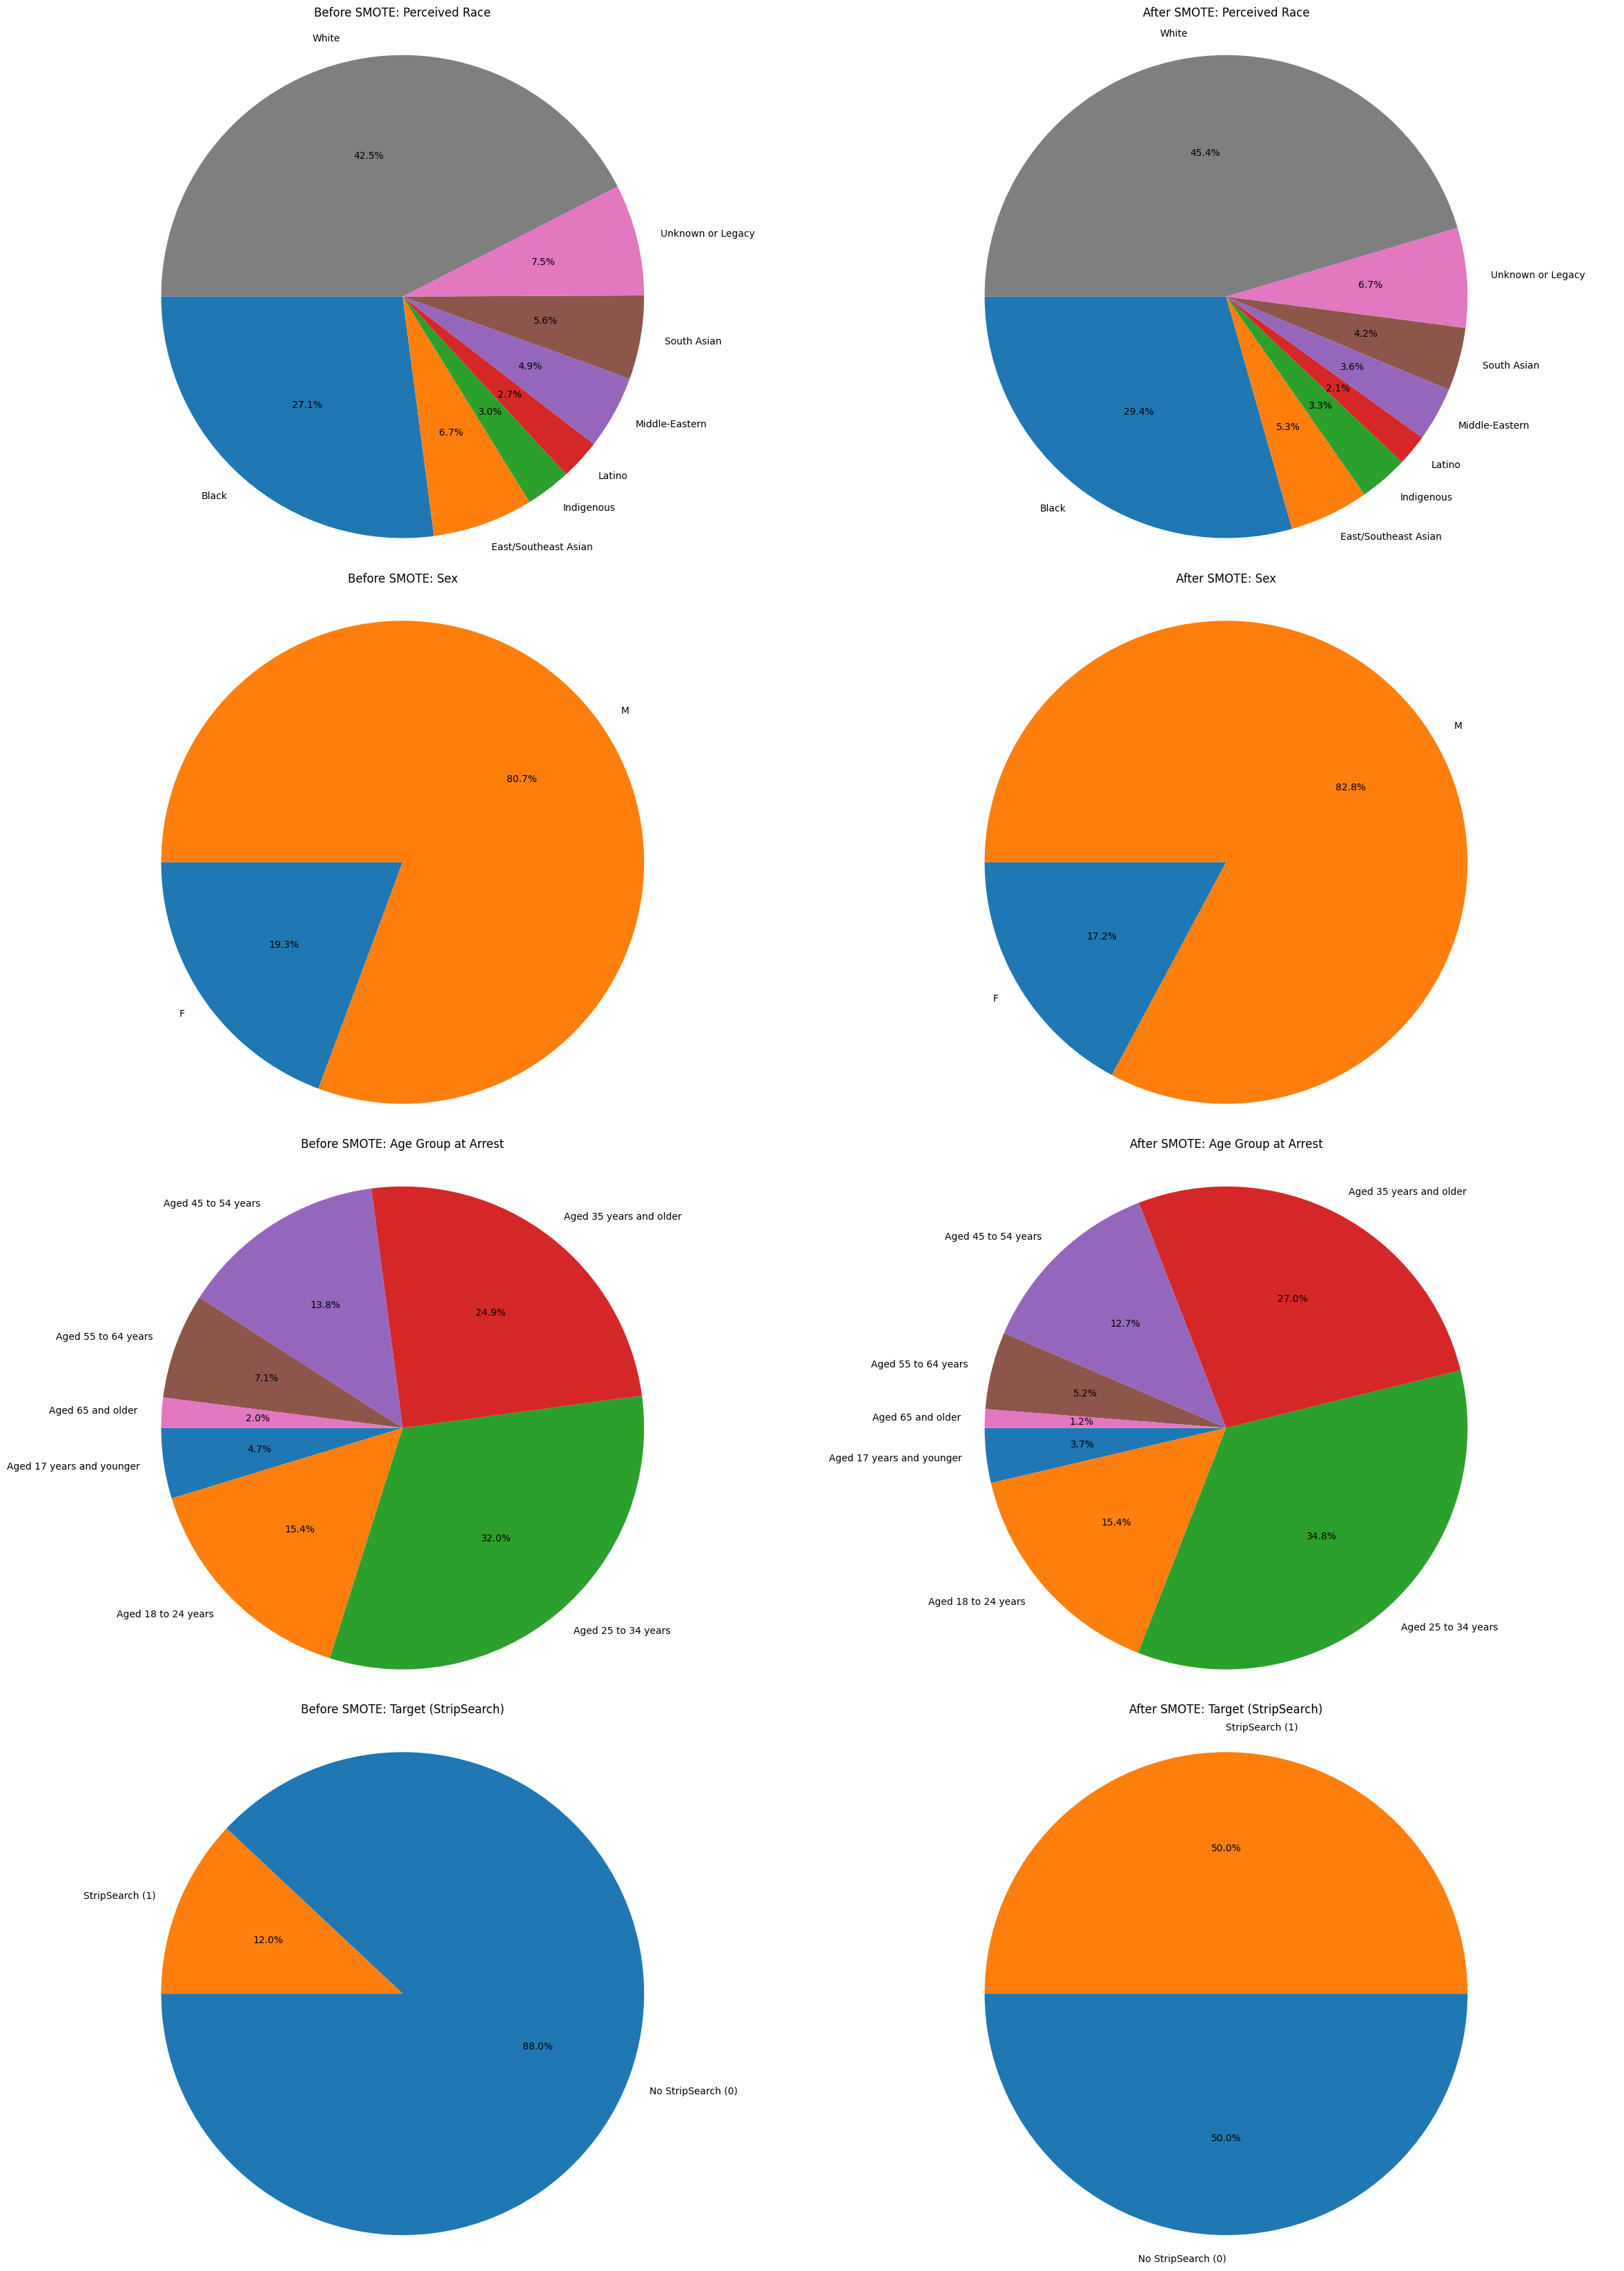

In [36]:
# Original v/s SMOTE dataset distribution across Race, Sex, Age, and Target (4x2 subplots)

feature_cols = unprocessed_baseline["preprocessor"].get_feature_names_out()

# Inverse-scale because X_tr / X_resampled are in standardized feature space
X_before_unscaled = unprocessed_baseline["scaler"].inverse_transform(X_tr)
X_after_unscaled = unprocessed_baseline["scaler"].inverse_transform(X_resampled)

df_before = pd.DataFrame(X_before_unscaled, columns=feature_cols)
df_after = pd.DataFrame(X_after_unscaled, columns=feature_cols)

def decode_onehot(df, prefix):
    cols = [c for c in feature_cols if c.startswith(prefix)]
    labels = [c.replace(prefix, "") for c in cols]
    idx = df[cols].to_numpy().argmax(axis=1)
    values = np.asarray(labels, dtype=object)[idx]
    return pd.Series(values), labels

def decode_age(df, age_label_map=None):
    ord_cols = list(unprocessed_baseline["preprocessor"].transformers_[1][2])
    age_pos = ord_cols.index("Age_group__at_arrest_")
    age_col = "ord_ordenc__Age_group__at_arrest_"

    age_categories = np.asarray(
        unprocessed_baseline["preprocessor"].named_transformers_["ord_ordenc"].categories_[age_pos],
        dtype=object,
    )

    codes = np.rint(df[age_col].to_numpy()).astype(int)
    valid = (codes >= 0) & (codes < len(age_categories))
    raw_values = np.where(valid, age_categories[np.clip(codes, 0, len(age_categories) - 1)], "Unknown")

    if age_label_map is None:
        age_label_map = {}

    values = pd.Series(raw_values, dtype=object).map(lambda x: age_label_map.get(x, x))
    labels = [age_label_map.get(x, x) for x in age_categories]
    return values, labels


def ordered_counts(series, labels):
    return series.value_counts().reindex(labels, fill_value=0)

# Decode groups from encoded features
race_before, race_labels = decode_onehot(df_before, "cat_ohe__Perceived_Race_")
race_after, _ = decode_onehot(df_after, "cat_ohe__Perceived_Race_")

sex_before, sex_labels = decode_onehot(df_before, "cat_ohe__Sex_")
sex_after, _ = decode_onehot(df_after, "cat_ohe__Sex_")

age_label_map = {
    0: "Aged 17 years and younger",
    1: "Aged 18 to 24 years",
    2: "Aged 25 to 34 years",
    3: "Aged 35 years and older",
    4: "Aged 45 to 54 years",
    5: "Aged 55 to 64 years",
    6: "Aged 65 and older",
}

age_before, age_labels = decode_age(df_before, age_label_map=age_label_map)
age_after, _ = decode_age(df_after, age_label_map=age_label_map)

target_labels = ["No StripSearch (0)", "StripSearch (1)"]
target_before = pd.Series(y_tr).astype(int).map({0: target_labels[0], 1: target_labels[1]})
target_after = pd.Series(y_resampled).astype(int).map({0: target_labels[0], 1: target_labels[1]})

plot_rows = [
    ("Perceived Race", race_before, race_after, race_labels),
    ("Sex", sex_before, sex_after, sex_labels),
    ("Age Group at Arrest", age_before, age_after, age_labels),
    ("Target (StripSearch)", target_before, target_after, target_labels),
]

fig, axes = plt.subplots(4, 2, figsize=(24,33))

for r, (title, before_s, after_s, labels) in enumerate(plot_rows):
    before_counts = ordered_counts(before_s, labels)
    after_counts = ordered_counts(after_s, labels)
    axes[r, 0].pie(before_counts.values, labels=before_counts.index, autopct="%1.1f%%", startangle=180 )
    axes[r, 0].set_title(f"Before SMOTE: {title}", pad=15)
    axes[r, 0].axis("equal")

    axes[r, 1].pie(after_counts.values, labels=after_counts.index, autopct="%1.1f%%", startangle=180)
    axes[r, 1].set_title(f"After SMOTE: {title}", pad=15)
    axes[r, 1].axis("equal")

plt.tight_layout()
plt.show()

### Neural Network

In [79]:
class MLPBaseline(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)   

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())

        avg_val_loss = np.mean(val_losses)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
            
    if best_state is not None:
        model.load_state_dict(best_state)

### Test Set Evaluation

In [80]:
def label_false_positives(X_test, y_test, y_pred):
    fps = np.zeros(y_pred.shape[0])
    y_truth = y_test.copy().reset_index(drop=True)
    test_copy = X_test.copy().reset_index(drop=True)
    for i in test_copy.itertuples():
        if y_pred[i[0]] == 1 and y_truth[i[0]] == 0:
            fps[i[0]] = 1
    test_copy["targetcol"] = np.round(fps, 2)
    return test_copy

def label_false_negatives(X_test, y_test, y_pred):
    fns = np.zeros(y_pred.shape[0])
    y_truth = y_test.copy().reset_index(drop=True)
    test_copy = X_test.copy().reset_index(drop=True)
    for i in test_copy.itertuples():
        if y_pred[i[0]] == 0 and y_truth[i[0]] == 1:
            fns[i[0]] = 1
    test_copy["targetcol"] = np.round(fns, 2)
    return test_copy


def make_loaders(X_train_np, y_train_np, batch_size=512, seed=42, val_size=0.1):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_np, y_train_np, test_size=val_size, random_state=seed, stratify=y_train_np
    )
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
    )


def evaluate_model(model, X_test_np, y_test_np):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
        logits = model(x)            
        logits = logits.reshape(-1)    # robust for [N] or [N,1]
        probs = torch.sigmoid(logits).cpu().numpy()

    y_pred = (probs >= 0.5).astype(int)
    y_true = np.asarray(y_test_np).astype(int).reshape(-1)

    return {
        "y_pred": y_pred,
        "y_prob": probs,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, probs),
    }


In [81]:
results = {} # store evaluation outputs and models for each case
X_test_for_labels = X_test.copy().reset_index(drop=True)   # raw/readable frame
y_test_series = y_test.copy().reset_index(drop=True)       # for our FP/FN funcs

for case in [unprocessed_baseline, baseline]:
    print(f"\nTraining {case['name']}...")
    train_loader, val_loader = make_loaders(
        case["X_train_np"], case["y_train_np"], batch_size=BATCH_SIZE, seed=SEED
    )

    model = MLPBaseline(input_dim=case["X_train_np"].shape[1]).to(DEVICE)
    train_model(model, train_loader, val_loader)

    eval_out = evaluate_model(model, case["X_test_np"], case["y_test_np"])
    results[case["name"]] = {
        **eval_out,
        "model": model,
    }

    print(
        f"{case['name']} | Acc={eval_out['accuracy']:.4f} | "
        f"F1={eval_out['f1']:.4f} | ROC-AUC={eval_out['roc_auc']:.4f}"
    )

# metric table
metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)

# FP/FN labeled tables by case
fp_tables = {}
fn_tables = {}
for case_name, out in results.items():
    fp_tables[case_name] = label_false_positives(X_test_for_labels, y_test_series, out["y_pred"])
    fn_tables[case_name] = label_false_negatives(X_test_for_labels, y_test_series, out["y_pred"])
    print(case_name, "| FP:", int(fp_tables[case_name]["targetcol"].sum()),
          "| FN:", int(fn_tables[case_name]["targetcol"].sum()))



Training Pre-baseline...
Epoch 1/40 - Train Loss: 0.3372 - Val Loss: 0.2599
Epoch 2/40 - Train Loss: 0.2526 - Val Loss: 0.2560
Epoch 3/40 - Train Loss: 0.2464 - Val Loss: 0.2541
Epoch 4/40 - Train Loss: 0.2432 - Val Loss: 0.2521
Epoch 5/40 - Train Loss: 0.2396 - Val Loss: 0.2528
Epoch 6/40 - Train Loss: 0.2380 - Val Loss: 0.2525
Epoch 7/40 - Train Loss: 0.2362 - Val Loss: 0.2530
Epoch 8/40 - Train Loss: 0.2346 - Val Loss: 0.2508
Epoch 9/40 - Train Loss: 0.2332 - Val Loss: 0.2503
Epoch 10/40 - Train Loss: 0.2326 - Val Loss: 0.2511
Epoch 11/40 - Train Loss: 0.2314 - Val Loss: 0.2505
Epoch 12/40 - Train Loss: 0.2310 - Val Loss: 0.2512
Epoch 13/40 - Train Loss: 0.2286 - Val Loss: 0.2491
Epoch 14/40 - Train Loss: 0.2285 - Val Loss: 0.2487
Epoch 15/40 - Train Loss: 0.2276 - Val Loss: 0.2481
Epoch 16/40 - Train Loss: 0.2265 - Val Loss: 0.2485
Epoch 17/40 - Train Loss: 0.2253 - Val Loss: 0.2500
Epoch 18/40 - Train Loss: 0.2248 - Val Loss: 0.2482
Epoch 19/40 - Train Loss: 0.2239 - Val Loss: 0.

,case,accuracy,f1,roc_auc
0,Pre-baseline,0.900046,0.451749,0.897147
1,Baseline,0.844345,0.527739,0.885616


Pre-baseline | FP: 277 | FN: 1024
Baseline | FP: 1598 | FN: 428


#### We take the encoded and smote balanced case as our Baseline model.

## Multi-adversarial debiasing (MADb)

- This is the in-processing debiasing variant for the NN Baseline. 
- Here we train two models, one the predictor and other which tries to find hidden adversary relationships from the predictor's output.


### MADb on 2 Attributes
-  Here we train predictor against multiple adversaries for `Perceived_Race`, `Sex`, and the `Race x Sex` intersection.

In [82]:
debiased1 = "Debiased-1"
db1_protected_cols = ["Perceived_Race", "Sex"] #db1 : debiased with race, sex and their intersection

db1 = prepare_smote_case_with_sensitive_labels(
    case_name=debiased1,
    preprocessor=preprocessor,
    x_train_raw=X_train_base,
    x_test_raw=X_test_base,
    y_train=y_train,
    y_test=y_test,
    protected_cols=db1_protected_cols,
    random_state=SEED,
)

# Add an intersection adversary so the representation is discouraged from encoding
# both single-attribute and intersectional sensitive signals.
race_targets = db1["protected_targets"]["Perceived_Race"]
sex_targets = db1["protected_targets"]["Sex"]
sex_cardinality = len(db1["protected_classes"]["Sex"])
db1["protected_targets"]["Race_Sex_intersection"] = race_targets * sex_cardinality + sex_targets
db1["protected_classes"]["Race_Sex_intersection"] = [
    f"{race}|{sex}"
    for race in db1["protected_classes"]["Perceived_Race"]
    for sex in db1["protected_classes"]["Sex"]
]

train_loader_db1, val_loader_db1, db1_protected_order = make_adversarial_loaders(
    db1["X_train_np"],
    db1["y_train_np"],
    db1["protected_targets"],
    batch_size=BATCH_SIZE,
    seed=SEED,
    val_size=0.1,
)

db1_model = MultiAdversarialMLP(
    input_dim=db1["X_train_np"].shape[1],
    protected_output_dims={
        name: len(db1["protected_classes"][name])
        for name in db1_protected_order
    },
).to(DEVICE)

db1_history = train_multi_adversarial_model(
    db1_model,
    train_loader_db1,
    val_loader_db1,
    db1_protected_order,
    device=DEVICE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    adv_lambda=1.0,
    adv_weight=0.5,
)

db1_eval = evaluate_multi_adversarial_model(
    db1_model,
    db1["X_test_np"],
    db1["y_test_np"],
    DEVICE,
)
results[debiased1] = {
    **db1_eval,
    "model": db1_model,
    "history": db1_history,
}

Epoch 1/40 | task_train=0.4538 | adv_train=4.3151 | task_val=0.3895 | adv_val=4.0702 | lambda=0.025
Epoch 2/40 | task_train=0.3841 | adv_train=4.0945 | task_val=0.3720 | adv_val=3.9412 | lambda=0.050
Epoch 3/40 | task_train=0.3683 | adv_train=3.9252 | task_val=0.3600 | adv_val=3.7586 | lambda=0.075
Epoch 4/40 | task_train=0.3589 | adv_train=3.9552 | task_val=0.3499 | adv_val=4.0378 | lambda=0.100
Epoch 5/40 | task_train=0.3509 | adv_train=3.9264 | task_val=0.3429 | adv_val=3.8265 | lambda=0.125
Epoch 6/40 | task_train=0.3439 | adv_train=3.9171 | task_val=0.3379 | adv_val=3.8535 | lambda=0.150
Epoch 7/40 | task_train=0.3368 | adv_train=3.9142 | task_val=0.3314 | adv_val=3.8800 | lambda=0.175
Epoch 8/40 | task_train=0.3316 | adv_train=3.9104 | task_val=0.3251 | adv_val=3.8903 | lambda=0.200
Epoch 9/40 | task_train=0.3266 | adv_train=3.9229 | task_val=0.3218 | adv_val=3.9273 | lambda=0.225
Epoch 10/40 | task_train=0.3232 | adv_train=3.9218 | task_val=0.3186 | adv_val=3.8517 | lambda=0.250

In [83]:
fp_tables[debiased1] = label_false_positives(X_test_for_labels, y_test_series, db1_eval["y_pred"])
fn_tables[debiased1] = label_false_negatives(X_test_for_labels, y_test_series, db1_eval["y_pred"])

print(
    f"{debiased1} | Acc={db1_eval['accuracy']:.4f} | "
    f"F1={db1_eval['f1']:.4f} | ROC-AUC={db1_eval['roc_auc']:.4f}"
)
print(
    debiased1,
    "| FP:", int(fp_tables[debiased1 ]["targetcol"].sum()),
    "| FN:", int(fn_tables[debiased1]["targetcol"].sum()),
)

metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)



Debiased-1 | Acc=0.8317 | F1=0.5216 | ROC-AUC=0.8854
Debiased-1 | FP: 1824 | FN: 366


,case,accuracy,f1,roc_auc
0,Pre-baseline,0.900046,0.451749,0.897147
1,Baseline,0.844345,0.527739,0.885616
2,Debiased-1,0.831746,0.521625,0.885375


### MADb on 3 Attributes


In [84]:
debiased2 = "Debiased-2"

db2 = prepare_smote_case_with_sensitive_labels(
    case_name=debiased2,
    preprocessor=preprocessor,
    x_train_raw=X_train_base,
    x_test_raw=X_test_base,
    y_train=y_train,
    y_test=y_test,
    protected_cols=["Perceived_Race", "Sex", "Age_group__at_arrest_"],
    random_state=SEED,
)

add_intersection_protected_target(db2, 'Race_Sex_intersection', ['Perceived_Race', 'Sex'], min_count=1)
add_intersection_protected_target(db2, 'Race_Age_intersection', ['Perceived_Race', 'Age_group__at_arrest_'], min_count=20)
add_intersection_protected_target(db2, 'Sex_Age_intersection', ['Sex', 'Age_group__at_arrest_'], min_count=20)
add_intersection_protected_target(db2, 'Race_Sex_Age_intersection', ['Perceived_Race', 'Sex', 'Age_group__at_arrest_'], min_count=20)

train_loader_db2, val_loader_db2, db2_protected_order = make_adversarial_loaders(
    db2["X_train_np"],
    db2["y_train_np"],
    db2["protected_targets"],
    batch_size=BATCH_SIZE,
    seed=SEED,
    val_size=0.1,
)

db2_model = MultiAdversarialMLP(
    input_dim=db2["X_train_np"].shape[1],
    protected_output_dims={
        name: len(db2["protected_classes"][name])
        for name in db2_protected_order
    },
).to(DEVICE)

db2_history = train_multi_adversarial_model(
    db2_model,
    train_loader_db2,
    val_loader_db2,
    db2_protected_order,
    device=DEVICE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    adv_lambda=1.0,
    adv_weight=0.5,
)

db2_eval = evaluate_multi_adversarial_model(
    db2_model,
    db2["X_test_np"],
    db2["y_test_np"],
    DEVICE,
)

results[debiased2] = {
    **db2_eval,
    "model": db2_model,
    "history": db2_history,
}

fp_tables[debiased2] = label_false_positives(X_test_for_labels, y_test_series, db2_eval["y_pred"])
fn_tables[debiased2] = label_false_negatives(X_test_for_labels, y_test_series, db2_eval["y_pred"])

print(
    f"{debiased2} | Acc={db2_eval['accuracy']:.4f} | "
    f"F1={db2_eval['f1']:.4f} | ROC-AUC={db2_eval['roc_auc']:.4f}"
)
print(
    debiased2,
    "| FP:", int(fp_tables[debiased2]["targetcol"].sum()),
    "| FN:", int(fn_tables[debiased2]["targetcol"].sum()),
)

metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)


Epoch 1/40 | task_train=0.4426 | adv_train=15.5962 | task_val=0.3895 | adv_val=14.9992 | lambda=0.025
Epoch 2/40 | task_train=0.3871 | adv_train=14.9297 | task_val=0.3751 | adv_val=14.7133 | lambda=0.050
Epoch 3/40 | task_train=0.3732 | adv_train=14.5316 | task_val=0.3626 | adv_val=14.0872 | lambda=0.075
Epoch 4/40 | task_train=0.3625 | adv_train=14.3429 | task_val=0.3540 | adv_val=14.2268 | lambda=0.100
Epoch 5/40 | task_train=0.3531 | adv_train=14.2730 | task_val=0.3475 | adv_val=14.1671 | lambda=0.125
Epoch 6/40 | task_train=0.3459 | adv_train=14.2697 | task_val=0.3399 | adv_val=14.3003 | lambda=0.150
Epoch 7/40 | task_train=0.3402 | adv_train=14.2602 | task_val=0.3351 | adv_val=14.1219 | lambda=0.175
Epoch 8/40 | task_train=0.3388 | adv_train=14.3002 | task_val=0.3295 | adv_val=14.0225 | lambda=0.200
Epoch 9/40 | task_train=0.3367 | adv_train=14.2973 | task_val=0.3269 | adv_val=14.3108 | lambda=0.225
Epoch 10/40 | task_train=0.3334 | adv_train=14.2985 | task_val=0.3252 | adv_val=14

,case,accuracy,f1,roc_auc
0,Pre-baseline,0.900046,0.451749,0.897147
1,Baseline,0.844345,0.527739,0.885616
2,Debiased-1,0.831746,0.521625,0.885375
3,Debiased-2,0.826905,0.514335,0.884137


### Disparity by Sex and Race


In [85]:
FINAL_CASES = ["Baseline", "Debiased-1", "Debiased-2"] 
missing_final = [name for name in FINAL_CASES if name not in results]
if missing_final:
    raise RuntimeError(f"Missing required final cases in results: {missing_final}")

protected_cols = ["Perceived_Race", "Sex", "Race_Sex_intersection"]

y_true = y_test.reset_index(drop=True).astype(int)
X_grp = X_test.reset_index(drop=True).copy()
X_grp["Race_Sex_intersection"] = (
    X_grp["Perceived_Race"].astype(str) + " | " + X_grp["Sex"].astype(str)
)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def group_error_table(X_raw, y_true, y_pred, group_col):
    df = pd.DataFrame({
        "group": X_raw[group_col].reset_index(drop=True),
        "y_true": y_true.reset_index(drop=True).astype(int),
        "y_pred": pd.Series(y_pred).reset_index(drop=True).astype(int)
    })

    rows = []
    for g, part in df.groupby("group"):
        yt = part["y_true"].to_numpy()
        yp = part["y_pred"].to_numpy()

        tp = int(((yt == 1) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        n = len(part)

        rows.append({
            "group": g,
            "count": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TPR": safe_div(tp, tp + fn),
            "FPR": safe_div(fp, fp + tn),
            "FNR": safe_div(fn, tp + fn),
            "SelectionRate": safe_div(tp + fp, n),
        })

    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

def disparity_summary(group_df, metrics=("TPR", "FPR", "FNR", "SelectionRate")):
    out = {}
    for metric in metrics:
        vals = group_df[metric].dropna()
        out[f"{metric}_gap"] = (vals.max() - vals.min()) if len(vals) else np.nan
    out["EO_gap_max"] = np.nanmax([out["TPR_gap"], out["FPR_gap"]])
    return out

group_tables = {}
summary_rows = []

for case_name in FINAL_CASES:
    out = results[case_name]
    y_pred = out["y_pred"]

    for col in protected_cols:
        gtab = group_error_table(X_grp, y_true, y_pred, col)
        group_tables[(case_name, col)] = gtab

        summary_rows.append({
            "case": case_name,
            "attribute": col,
            "accuracy": out["accuracy"],
            "f1": out["f1"],
            "roc_auc": out["roc_auc"],
            **disparity_summary(gtab),
        })

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["attribute", "EO_gap_max", "FNR_gap", "FPR_gap", "f1"],
    ascending=[True, True, True, True, False],
).reset_index(drop=True)

for (case_name, col), tbl in group_tables.items():
    print(f"\n=== {case_name} | {col} ===")
    display(tbl)

print("\n=== Disparity Summary (lower gaps are better) ===")
display(summary_df)

FINAL_DIR = os.path.join(OUT_BASE_DIR, "final_evaluation")
DISPARITY_DIR = os.path.join(FINAL_DIR, "disparity")
os.makedirs(DISPARITY_DIR, exist_ok=True)

summary_df.to_csv(os.path.join(DISPARITY_DIR, "disparity_summary_final_cases.csv"), index=False)

def case_slug(name):
    return name.lower().replace("-", "_").replace(" ", "_")

for (case_name, col), tbl in group_tables.items():
    tbl.to_csv(
        os.path.join(DISPARITY_DIR, f"group_table_{case_slug(case_name)}_{col}.csv"),
        index=False,
    )



=== Baseline | Perceived_Race ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White,5501,548,4030,748,175,0.757953,0.156551,0.242047,0.235594
1,Black,3464,368,2458,517,121,0.752556,0.173782,0.247444,0.255485
2,Unknown or Legacy,1135,72,895,132,36,0.666667,0.128530,0.333333,0.179736
3,East/Southeast Asian,839,36,721,54,28,0.562500,0.069677,0.437500,0.107271
4,South Asian,712,32,615,48,17,0.653061,0.072398,0.346939,0.112360
5,Middle-Eastern,623,23,534,42,24,0.489362,0.072917,0.510638,0.104334
6,Indigenous,392,44,303,33,12,0.785714,0.098214,0.214286,0.196429
7,Latino,350,9,302,24,15,0.375000,0.073620,0.625000,0.094286



=== Baseline | Sex ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,M,10477,951,7840,1348,338,0.737781,0.146713,0.262219,0.219433
1,F,2539,181,2018,250,90,0.667897,0.110229,0.332103,0.169752



=== Baseline | Race_Sex_intersection ===


...

,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,M,10477,1003,7613,1575,286,0.778123,0.171419,0.221877,0.246063
1,F,2539,190,1957,311,81,0.701107,0.137125,0.298893,0.197322



=== Debiased-2 | Race_Sex_intersection ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White | M,4273,446,3071,649,107,0.806510,0.174462,0.193490,0.256260
1,Black | M,2864,330,2003,426,105,0.758621,0.175381,0.241379,0.263966
2,White | F,1228,119,900,158,51,0.700000,0.149338,0.300000,0.225570
3,Unknown or Legacy | M,936,71,677,166,22,0.763441,0.196916,0.236559,0.253205
4,East/Southeast Asian | M,695,41,551,86,17,0.706897,0.135008,0.293103,0.182734
5,South Asian | M,610,35,480,86,9,0.795455,0.151943,0.204545,0.198361
6,Black | F,600,34,462,84,20,0.629630,0.153846,0.370370,0.196667
7,Middle-Eastern | M,552,31,428,82,11,0.738095,0.160784,0.261905,0.204710
8,Latino | M,290,10,226,43,11,0.476190,0.159851,0.523810,0.182759
9,Indigenous | M,257,39,177,37,4,0.906977,0.172897,0.093023,0.295720



=== Disparity Summary (lower gaps are better) ===


,case,attribute,accuracy,f1,roc_auc,TPR_gap,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Debiased-2,Perceived_Race,0.826905,0.514335,0.884137,0.333333,0.050764,0.333333,0.094184,0.333333
1,Debiased-1,Perceived_Race,0.831746,0.521625,0.885375,0.375000,0.061860,0.375000,0.107642,0.375000
2,Baseline,Perceived_Race,0.844345,0.527739,0.885616,0.410714,0.104104,0.410714,0.161199,0.410714
3,Baseline,Race_Sex_intersection,0.844345,0.527739,0.885616,0.503876,0.184438,0.503876,0.245965,0.503876
4,Debiased-2,Race_Sex_intersection,0.826905,0.514335,0.884137,0.523810,0.144284,0.523810,0.195720,0.523810
5,Debiased-1,Race_Sex_intersection,0.831746,0.521625,0.885375,0.666667,0.105881,0.666667,0.182418,0.666667
6,Debiased-1,Sex,0.831746,0.521625,0.885375,0.028667,0.019850,0.028667,0.030686,0.028667
7,Baseline,Sex,0.844345,0.527739,0.885616,0.069885,0.036484,0.069885,0.049681,0.069885
8,Debiased-2,Sex,0.826905,0.514335,0.884137,0.077016,0.034294,0.077016,0.048741,0.077016


1. **Baseline**
- Baseline is the SMOTE-trained neural model used as the control model for fairness and recourse comparisons.

2. **Debiased-1 (MADb on 2 attributes)**
- Adds adversarial heads for `Perceived_Race`, `Sex`, and `Race x Sex` intersection.

3. **Debiased-2 (MADb on 3 attributes)**
- Extends Debiased-1 with age-aware adversaries and three-way intersectional debiasing.

4. **Interpretation**
- After comparing utility and gap metrics jointly, lower disparity with stable utility indicates better deployment-readiness.

## Explanation Tables


### How to Read the Explanation Tables
- Each row is a discovered subgroup pattern over `Perceived_Race`, `Sex`, and `Age_group__at_arrest_`.
- `targetcol` is the false-positive subgroup rate contribution returned by the explanation miner.
- Higher `targetcol` rows indicate subgroups contributing more strongly to false-positive concentration.
- Use the same top-k threshold across all three final cases for fair comparison.


### Baseline


In [86]:
exp_mod = globals().get('exptb', globals().get('exptbl'))
if exp_mod is None:
    raise NameError('Neither exptb nor exptbl is available. Import exp as exptb first.')

FINAL_CASES = ['Baseline', 'Debiased-1', 'Debiased-2']
for _name in FINAL_CASES:
    if _name not in results:
        raise RuntimeError(f"Missing '{_name}' in results. Run model training cells first.")

group_cols = ['Perceived_Race', 'Sex', 'Age_group__at_arrest_']
exp_table_cols = group_cols + ['targetcol']
min_sup = 0.1

def _sanitize_case(name):
    return name.lower().replace('-', '_').replace(' ', '_')

X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)

FINAL_DIR = os.path.join(OUT_BASE_DIR, 'final_evaluation')
EXPLAIN_DIR = os.path.join(FINAL_DIR, 'explanations')
os.makedirs(EXPLAIN_DIR, exist_ok=True)

explanation_fp_tables = {}
explanation_paths = {}

def build_fp_explanation_for_case(case_name, top_k=12):
    y_pred = results[case_name]['y_pred']
    x_res_fp = label_false_positives(X_test_exp, y_test_series, y_pred)

    slug = _sanitize_case(case_name)
    temp_fp = os.path.join(FP_DIR, f'temp_{slug}_fp.csv')
    target_fp = os.path.join(FP_DIR, f'target_{slug}_fp.csv')

    x_res_fp[exp_table_cols].to_csv(temp_fp, index=False)
    pd.DataFrame().to_csv(target_fp, index=False)

    out_fp = exp_mod.calculate_table(target_fp, temp_fp, target_fp, min_support_param=min_sup)
    fp_df = pd.read_csv(out_fp, sep=';').sort_values(by=['targetcol'], ascending=[False]).reset_index(drop=True)

    full_csv = os.path.join(EXPLAIN_DIR, f'{slug}_fp_table_full.csv')
    top_csv = os.path.join(EXPLAIN_DIR, f'{slug}_fp_table_top{top_k}.csv')
    fp_df.to_csv(full_csv, index=False)
    fp_df.head(top_k).to_csv(top_csv, index=False)

    explanation_fp_tables[case_name] = fp_df
    explanation_paths[case_name] = {'full': full_csv, 'top': top_csv}

    print(case_name)
    print('full csv:', full_csv)
    print(f'top{top_k} csv:', top_csv)
    display(fp_df.head(top_k))

build_fp_explanation_for_case('Baseline', top_k=12)


Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: nn_madb_outputs/fp_analysis/target_baseline_fp.csv nn_madb_outputs/fp_analysis/temp_baseline_fp.csv 3 15 0 nn_madb_outputs/fp_analysis/target_baseline_fp.csv 0.1
Time: 0:00:12.634625
Baseline
full csv: nn_madb_outputs/final_evaluation/explanations/baseline_fp_table_full.csv
top12 csv: nn_madb_outputs/final_evaluation/explanations/baseline_fp_table_top12.csv


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
0,7,*,2,0.177,1687
1,0,1,*,0.156,2864
2,*,1,2,0.155,3378
3,*,1,1,0.153,1598
4,*,*,2,0.150,4237
5,0,*,*,0.149,3464
6,*,*,1,0.142,2012
7,7,*,*,0.136,5501
8,7,*,3,0.136,1511
9,*,1,3,0.130,2601


### Debiased-1 (MADb on 2 Attributes)


In [87]:
build_fp_explanation_for_case('Debiased-1', top_k=12)

Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: nn_madb_outputs/fp_analysis/target_debiased_1_fp.csv nn_madb_outputs/fp_analysis/temp_debiased_1_fp.csv 3 15 0 nn_madb_outputs/fp_analysis/target_debiased_1_fp.csv 0.1
Time: 0:00:12.177163
Debiased-1
full csv: nn_madb_outputs/final_evaluation/explanations/debiased_1_fp_table_full.csv
top12 csv: nn_madb_outputs/final_evaluation/explanations/debiased_1_fp_table_top12.csv


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
0,7,*,2,0.177,1687
1,*,1,1,0.171,1598
2,*,*,2,0.164,4237
3,*,*,1,0.164,2012
4,*,1,2,0.164,3378
5,7,*,3,0.156,1511
6,0,1,*,0.154,2864
7,*,1,3,0.150,2601
8,0,*,*,0.150,3464
9,7,*,*,0.146,5501


### Debiased-2 (MADb on 3 Attributes)


In [88]:
build_fp_explanation_for_case('Debiased-2', top_k=12)

Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: nn_madb_outputs/fp_analysis/target_debiased_2_fp.csv nn_madb_outputs/fp_analysis/temp_debiased_2_fp.csv 3 15 0 nn_madb_outputs/fp_analysis/target_debiased_2_fp.csv 0.1
Time: 0:00:11.797107
Debiased-2
full csv: nn_madb_outputs/final_evaluation/explanations/debiased_2_fp_table_full.csv
top12 csv: nn_madb_outputs/final_evaluation/explanations/debiased_2_fp_table_top12.csv


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
0,7,*,2,0.165,1687
1,*,1,2,0.157,3378
2,7,1,*,0.152,4273
3,*,*,2,0.152,4237
4,*,1,1,0.151,1598
5,*,1,3,0.151,2601
6,*,1,*,0.150,10477
7,*,*,1,0.150,2012
8,*,1,4,0.149,1479
9,0,*,*,0.147,3464


## Evaluation - Seed Runs

In [109]:
SEED_RUNS = [1, 2, 3, 4, 5]
SEED_EPOCHS = 40

MODELS_DIR = os.path.join('.', 'nn_madb_outputs', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

BASELINE_SEED_PKL = os.path.join(MODELS_DIR, 'seed_runs_baseline.pkl')
DEBIASED1_SEED_PKL = os.path.join(MODELS_DIR, 'seed_runs_debiased_1.pkl')
DEBIASED2_SEED_PKL = os.path.join(MODELS_DIR, 'seed_runs_debiased_2.pkl')

In [110]:
#helper functions for reporducibility
def _load_pickle(path):
    if os.path.isfile(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None


def _save_pickle(path, obj):
    tmp = path + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(obj, f)
    os.replace(tmp, path)


def run_baseline_seed(seed, epochs):
    case = run_case(
        f'Baseline | seed {seed}',
        preprocessor,
        X_train_base,
        X_test_base,
        y_train,
        y_test_np,
        smote=True,
        random_state=seed,
    )
    train_loader, val_loader = make_loaders(case['X_train_np'], case['y_train_np'], batch_size=BATCH_SIZE, seed=seed)
    model = MLPBaseline(input_dim=case['X_train_np'].shape[1]).to(DEVICE)
    train_model(model, train_loader, val_loader, epochs=epochs)
    eval_out = evaluate_model(model, case['X_test_np'], case['y_test_np'])
    case_results = {case['name']: {**eval_out, 'model': model}}
    return case, case_results, model, eval_out


def run_debiased1_seed(seed, epochs, adv_weight=0.5):
    case_name = f'Debiased-1 | seed {seed}'
    case_cfg = prepare_smote_case_with_sensitive_labels(
        case_name=case_name,
        preprocessor=preprocessor,
        x_train_raw=X_train_base,
        x_test_raw=X_test_base,
        y_train=y_train,
        y_test=y_test,
        protected_cols=['Perceived_Race', 'Sex'],
        random_state=seed,
    )
    add_intersection_protected_target(case_cfg, 'Race_Sex_intersection', ['Perceived_Race', 'Sex'], min_count=1)

    train_loader, val_loader, protected_order = make_adversarial_loaders(
        case_cfg['X_train_np'], case_cfg['y_train_np'], case_cfg['protected_targets'],
        batch_size=BATCH_SIZE, seed=seed, val_size=0.1,
    )

    model = MultiAdversarialMLP(
        input_dim=case_cfg['X_train_np'].shape[1],
        protected_output_dims={k: len(case_cfg['protected_classes'][k]) for k in protected_order},
    ).to(DEVICE)

    history = train_multi_adversarial_model(
        model, train_loader, val_loader, protected_order,
        device=DEVICE, epochs=epochs, lr=LR, weight_decay=WEIGHT_DECAY,
        patience=PATIENCE, adv_lambda=1.0, adv_weight=adv_weight,
    )

    eval_out = evaluate_multi_adversarial_model(model, case_cfg['X_test_np'], case_cfg['y_test_np'], DEVICE)
    case_results = {case_name: {**eval_out, 'model': model, 'history': history}}
    return case_cfg, case_results, model, eval_out


def run_debiased2_seed(seed, epochs, adv_weight=0.5):
    case_name = f'Debiased-2 | seed {seed}'
    case_cfg = prepare_smote_case_with_sensitive_labels(
        case_name=case_name,
        preprocessor=preprocessor,
        x_train_raw=X_train_base,
        x_test_raw=X_test_base,
        y_train=y_train,
        y_test=y_test,
        protected_cols=['Perceived_Race', 'Sex', 'Age_group__at_arrest_'],
        random_state=seed,
    )

    add_intersection_protected_target(case_cfg, 'Race_Sex_intersection', ['Perceived_Race', 'Sex'], min_count=1)
    add_intersection_protected_target(case_cfg, 'Race_Age_intersection', ['Perceived_Race', 'Age_group__at_arrest_'], min_count=20)
    add_intersection_protected_target(case_cfg, 'Sex_Age_intersection', ['Sex', 'Age_group__at_arrest_'], min_count=20)
    add_intersection_protected_target(case_cfg, 'Race_Sex_Age_intersection', ['Perceived_Race', 'Sex', 'Age_group__at_arrest_'], min_count=20)

    train_loader, val_loader, protected_order = make_adversarial_loaders(
        case_cfg['X_train_np'], case_cfg['y_train_np'], case_cfg['protected_targets'],
        batch_size=BATCH_SIZE, seed=seed, val_size=0.1,
    )

    model = MultiAdversarialMLP(
        input_dim=case_cfg['X_train_np'].shape[1],
        protected_output_dims={k: len(case_cfg['protected_classes'][k]) for k in protected_order},
    ).to(DEVICE)

    history = train_multi_adversarial_model(
        model, train_loader, val_loader, protected_order,
        device=DEVICE, epochs=epochs, lr=LR, weight_decay=WEIGHT_DECAY,
        patience=PATIENCE, adv_lambda=1.0, adv_weight=adv_weight,
    )

    eval_out = evaluate_multi_adversarial_model(model, case_cfg['X_test_np'], case_cfg['y_test_np'], DEVICE)
    case_results = {case_name: {**eval_out, 'model': model, 'history': history}}
    return case_cfg, case_results, model, eval_out

In [111]:
#if available load existing seed runs otherwise run and save them for future use
baseline_seed_runs = _load_pickle(BASELINE_SEED_PKL)
debiased1_seed_runs = _load_pickle(DEBIASED1_SEED_PKL)
debiased2_seed_runs = _load_pickle(DEBIASED2_SEED_PKL)

if baseline_seed_runs is None or debiased1_seed_runs is None or debiased2_seed_runs is None:
    baseline_seed_runs = []
    debiased1_seed_runs = []
    debiased2_seed_runs = []

    for seed in SEED_RUNS:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        baseline_seed_runs.append(run_baseline_seed(seed, SEED_EPOCHS))
        debiased1_seed_runs.append(run_debiased1_seed(seed, SEED_EPOCHS, adv_weight=0.5))
        debiased2_seed_runs.append(run_debiased2_seed(seed, SEED_EPOCHS, adv_weight=0.5))

    _save_pickle(BASELINE_SEED_PKL, baseline_seed_runs)
    _save_pickle(DEBIASED1_SEED_PKL, debiased1_seed_runs)
    _save_pickle(DEBIASED2_SEED_PKL, debiased2_seed_runs)
    print('Saved seeded model families to:', BASELINE_SEED_PKL, DEBIASED1_SEED_PKL, DEBIASED2_SEED_PKL)
else:
    print('Loaded seeded model families from:', BASELINE_SEED_PKL, DEBIASED1_SEED_PKL, DEBIASED2_SEED_PKL)

print('Seed run counts:', len(baseline_seed_runs), len(debiased1_seed_runs), len(debiased2_seed_runs))

Loaded seeded model families from: ./nn_madb_outputs/models/seed_runs_baseline.pkl ./nn_madb_outputs/models/seed_runs_debiased_1.pkl ./nn_madb_outputs/models/seed_runs_debiased_2.pkl
Seed run counts: 5 5 5


Total Seeded runs duration on mac m1 air:  24m 17.8s

### Utility Summary

In [112]:
def _extract_seed_metrics(runs, label):
    rows = []
    for seed_idx, run in enumerate(runs, start=1):
        eval_out = run[3]
        rows.append({
            'case': label,
            'seed': seed_idx,
            'accuracy': eval_out.get('accuracy', np.nan),
            'f1': eval_out.get('f1', np.nan),
            'roc_auc': eval_out.get('roc_auc', np.nan),
        })
    return pd.DataFrame(rows)

utility_seed_df = pd.concat([
    _extract_seed_metrics(baseline_seed_runs, 'Baseline'),
    _extract_seed_metrics(debiased1_seed_runs, 'Debiased-1'),
    _extract_seed_metrics(debiased2_seed_runs, 'Debiased-2'),
], ignore_index=True)

utility_summary_df = utility_seed_df.groupby('case', as_index=False).agg(
    accuracy=('accuracy', 'mean'),
    f1=('f1', 'mean'),
    roc_auc=('roc_auc', 'mean'),
)

FINAL_DIR = os.path.join(OUT_BASE_DIR, 'final_evaluation')
SEEDED_DIR = os.path.join(FINAL_DIR, 'seeded')
os.makedirs(SEEDED_DIR, exist_ok=True)
utility_seed_df.to_csv(os.path.join(SEEDED_DIR, 'utility_seed_metrics.csv'), index=False)
utility_summary_df.to_csv(os.path.join(SEEDED_DIR, 'utility_summary.csv'), index=False)

display(utility_summary_df.sort_values('accuracy', ascending=False))

,case,accuracy,f1,roc_auc
0,Baseline,0.840012,0.525367,0.884650
1,Debiased-1,0.838384,0.522102,0.883138
2,Debiased-2,0.833420,0.515682,0.881636


### Fairness Plots


In [113]:
X_eval = X_test.reset_index(drop=True).copy()
y_eval = y_test.reset_index(drop=True).astype(int)
X_eval['Race_Sex_intersection'] = X_eval['Perceived_Race'].astype(str) + ' | ' + X_eval['Sex'].astype(str)

fairness_attrs = ['Perceived_Race', 'Sex', 'Race_Sex_intersection']

In [105]:
def _group_fpr_table(y_true, y_pred, grp):
    df = pd.DataFrame({'group': grp, 'y_true': y_true.astype(int), 'y_pred': pd.Series(y_pred).astype(int)})
    rows = []
    for group, part in df.groupby('group'):
        yt = part['y_true'].to_numpy()
        yp = part['y_pred'].to_numpy()
        fp = int(((yt == 0) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        rows.append({'group': group, 'FPR': fp / (fp + tn) if (fp + tn) else np.nan})
    return pd.DataFrame(rows)


def _avg_pairwise_gap(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        return np.nan
    diffs = [abs(a - b) for a, b in combinations(vals, 2)]
    return float(np.mean(diffs)) if diffs else np.nan


def _seeded_fairness_rows(runs, label):
    rows = []
    for seed_idx, run in enumerate(runs, start=1):
        case_name = run[0]['name']
        y_pred = run[1][case_name]['y_pred']

        attr_gaps = {}
        for attr in fairness_attrs:
            tbl = _group_fpr_table(y_eval, y_pred, X_eval[attr])
            attr_gaps[attr] = _avg_pairwise_gap(tbl['FPR'])

        rows.append({
            'case': label,
            'seed': seed_idx,
            'Perceived_Race_gap': attr_gaps['Perceived_Race'],
            'Sex_gap': attr_gaps['Sex'],
            'Race_Sex_intersection_gap': attr_gaps['Race_Sex_intersection'],
            'avg_gap': np.nanmean(list(attr_gaps.values())),
        })
    return pd.DataFrame(rows)

In [114]:
# Aggregate all seed run for fairness metrics into one DataFrame
seeded_fairness_df = pd.concat([ 
    _seeded_fairness_rows(baseline_seed_runs, 'Baseline'),
    _seeded_fairness_rows(debiased1_seed_runs, 'Debiased-1'),
    _seeded_fairness_rows(debiased2_seed_runs, 'Debiased-2'),
], ignore_index=True)

In [ ]:
#fairness summary table (utility + fairness gaps)
def _pairwise_gap_stats(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size < 2:
        return np.nan, np.nan
    diffs = [abs(a - b) for a, b in combinations(vals, 2)]
    return float(np.mean(diffs)), float(np.max(diffs))

fairness_attrs_full = ['Perceived_Race', 'Sex', 'Age_group__at_arrest_', 'Race_Sex_intersection']

if 'FINAL_CASES' in globals():
    __EVAL_CASES = list(FINAL_CASES)
elif 'final_cases' in globals():
    __EVAL_CASES = list(final_cases)
else:
    __EVAL_CASES = ['Baseline', 'Debiased-1', 'Debiased-2']

for _name in __EVAL_CASES:
    if _name not in results:
        raise RuntimeError(f"Missing '{_name}' in results for fairness summary table.")

FINAL_CASES = __EVAL_CASES
final_cases = __EVAL_CASES

if 'X_eval_detail' not in globals() or 'y_true_detail' not in globals():
    if 'X_test' not in globals() or 'y_test' not in globals():
        raise RuntimeError("X_test/y_test are required to build fairness detail tables.")
    X_eval_detail = X_test.reset_index(drop=True).copy()
    y_true_detail = y_test.reset_index(drop=True).astype(int)
    if 'Race_Sex_intersection' not in X_eval_detail.columns:
        X_eval_detail['Race_Sex_intersection'] = (
            X_eval_detail['Perceived_Race'].astype(str) + ' | ' + X_eval_detail['Sex'].astype(str)
        )

if '_group_metric_table' not in globals():
    def _group_metric_table(y_true, y_pred, group_series):
        df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': group_series.astype(str)})
        rows = []
        for g, s in df.groupby('group'):
            tp = ((s.y_true == 1) & (s.y_pred == 1)).sum()
            tn = ((s.y_true == 0) & (s.y_pred == 0)).sum()
            fp = ((s.y_true == 0) & (s.y_pred == 1)).sum()
            fn = ((s.y_true == 1) & (s.y_pred == 0)).sum()
            pos = tp + fn
            neg = tn + fp
            rows.append({
                'group': g,
                'count': int(len(s)),
                'TP': int(tp),
                'TN': int(tn),
                'FP': int(fp),
                'FN': int(fn),
                'TPR': (tp / pos) if pos else np.nan,
                'FPR': (fp / neg) if neg else np.nan,
                'FNR': (fn / pos) if pos else np.nan,
                'SelectionRate': ((tp + fp) / len(s)) if len(s) else np.nan,
            })
        return pd.DataFrame(rows)

case_fairness_rows = []
attr_metric_gap_rows = []
# for case_name in final_cases:
for case_name in __EVAL_CASES:
    metric_gaps = {m: [] for m in ['TPR', 'FPR', 'FNR', 'SelectionRate']}

    for attr in fairness_attrs_full:
        tbl = _group_metric_table(y_true_detail, results[case_name]['y_pred'], X_eval_detail[attr])
        for metric in ['TPR', 'FPR', 'FNR', 'SelectionRate']:
            avg_gap, max_gap = _pairwise_gap_stats(tbl[metric].values)
            metric_gaps[metric].append(avg_gap)
            attr_metric_gap_rows.append({
                'attribute': attr,
                'metric': metric,
                'case': case_name,
                'avg_gap': avg_gap,
                'max_gap': max_gap,
            })

    tpr_gap = float(np.nanmean(metric_gaps['TPR']))
    fpr_gap = float(np.nanmean(metric_gaps['FPR']))
    fnr_gap = float(np.nanmean(metric_gaps['FNR']))
    sel_gap = float(np.nanmean(metric_gaps['SelectionRate']))

    case_fairness_rows.append({
        'case': case_name,
        'accuracy': results[case_name]['accuracy'],
        'f1': results[case_name]['f1'],
        'roc_auc': results[case_name]['roc_auc'],
        'TPR_gap': tpr_gap,
        'FPR_gap': fpr_gap,
        'FNR_gap': fnr_gap,
        'SelectionRate_gap': sel_gap,
        'EO_gap_max': np.nanmax([tpr_gap, fpr_gap]),
    })

case_fairness_summary = pd.DataFrame(case_fairness_rows)
print('Case fairness summary')
display(case_fairness_summary.sort_values('EO_gap_max'))

Case fairness summary


,case,accuracy,f1,roc_auc,TPR_gap,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
2,Debiased-2,0.826905,0.514335,0.884137,0.101987,0.031395,0.101987,0.051428,0.101987
1,Debiased-1,0.831746,0.521625,0.885375,0.112978,0.039924,0.112978,0.061679,0.112978
0,Baseline,0.844345,0.527739,0.885616,0.131288,0.053299,0.131288,0.076045,0.131288


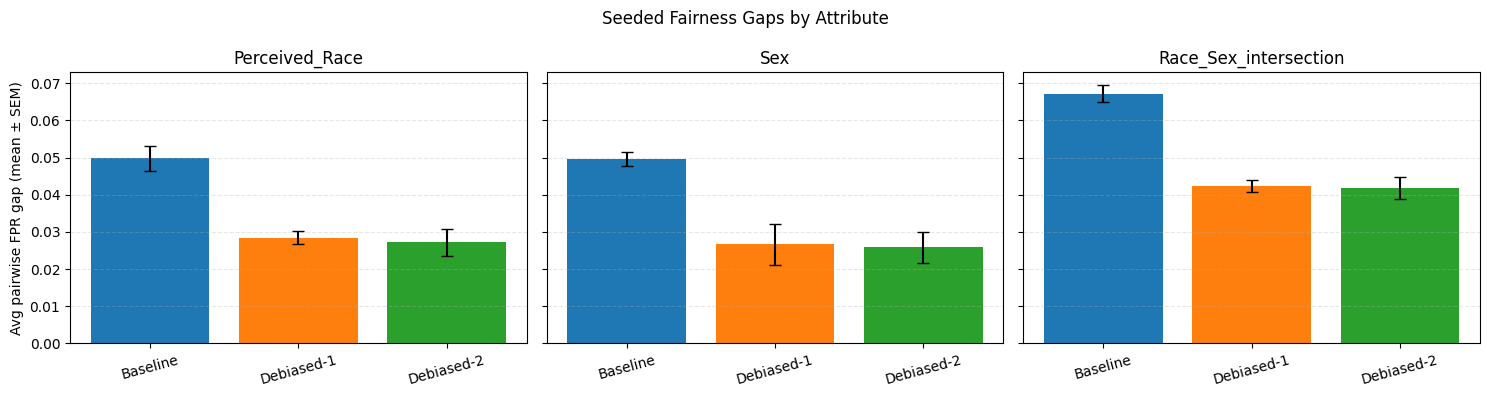

In [116]:
fpr_gap_ci = seeded_fairness_df.groupby('case')['avg_gap'].agg(['mean', 'std', 'count']).rename(columns={'mean': 'avg_gap_metric'})
fpr_gap_ci['gap_sem'] = (fpr_gap_ci['std'] / np.sqrt(fpr_gap_ci['count'].clip(lower=1))).fillna(0.0)

acc_sem_df = utility_seed_df.groupby('case')['accuracy'].agg(['std', 'count'])
acc_sem_df['accuracy_sem'] = (acc_sem_df['std'] / np.sqrt(acc_sem_df['count'].clip(lower=1))).fillna(0.0)

SEEDED_DIR = os.path.join(OUT_BASE_DIR, 'final_evaluation', 'seeded')
seeded_fairness_df.to_csv(os.path.join(SEEDED_DIR, 'seeded_fairness_gaps.csv'), index=False)
fpr_gap_ci.reset_index().to_csv(os.path.join(SEEDED_DIR, 'fpr_gap_ci.csv'), index=False)

plot_cols = ['Perceived_Race_gap', 'Sex_gap', 'Race_Sex_intersection_gap']
plot_df = seeded_fairness_df.groupby('case')[plot_cols].mean().reindex(['Baseline', 'Debiased-1', 'Debiased-2'])
plot_sem = seeded_fairness_df.groupby('case')[plot_cols].sem().reindex(['Baseline', 'Debiased-1', 'Debiased-2']).fillna(0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for idx, col in enumerate(plot_cols):
    ax = axes[idx]
    ax.bar(plot_df.index, plot_df[col], yerr=plot_sem[col], capsize=4, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(col.replace('_gap', ''))
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_ylabel('Avg pairwise FPR gap (mean ± SEM)')
plt.suptitle('Seeded Fairness Gaps by Attribute')
plt.tight_layout()
plt.show()

In [117]:
#Detailed fairness  
final_cases = ['Baseline', 'Debiased-1', 'Debiased-2']
for name in final_cases:
    if name not in results:
        raise RuntimeError(f"Missing '{name}' in results.")

if 'explanation_fp_tables' not in globals():
    raise RuntimeError('Explanation tables are not built. Run Baseline/Debiased explanation cells first.')

group_cols = ['Perceived_Race', 'Sex', 'Age_group__at_arrest_']
X_eval_detail = X_test.reset_index(drop=True).copy()
y_true_detail = y_test.reset_index(drop=True).astype(int)

X_eval_detail['Race_Sex_intersection'] = (
    X_eval_detail['Perceived_Race'].astype(str) + ' | ' + X_eval_detail['Sex'].astype(str)
)
X_eval_detail['Race_Sex_Age_intersection'] = (
    X_eval_detail['Perceived_Race'].astype(str)
    + ' | ' + X_eval_detail['Sex'].astype(str)
    + ' | ' + X_eval_detail['Age_group__at_arrest_'].astype(str)
)

#inverse maps for explanation-table decoding
inv_maps = {}
for col in group_cols:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str))
    inv_maps[col] = {str(i): v for i, v in enumerate(le.classes_)}

def _decode_expl_col(series, inv_map):
    def _d(x):
        sx = str(x)
        if sx == '*':
            return sx
        return inv_map.get(sx, x)
    return series.apply(_d)

#FP subgroup rates outer-join table from explanation FP tables
fp_cols = ['Perceived_Race', 'Sex', 'Age_group__at_arrest_', 'support', 'targetcol']

def _prep_fp_table(case_name, alias):
    df = explanation_fp_tables[case_name][fp_cols].copy()
    for col in group_cols:
        df[col] = _decode_expl_col(df[col], inv_maps[col])
    df = df.rename(columns={
        'support': f'support_{alias}',
        'targetcol': f'fp_rate_{alias}',
    })
    df[f'present_{alias}'] = True
    return df

fp_baseline = _prep_fp_table('Baseline', 'baseline')
fp_deb1 = _prep_fp_table('Debiased-1', 'debiased_1')
fp_deb2 = _prep_fp_table('Debiased-2', 'debiased_2')

fp_outer = fp_baseline.merge(fp_deb1, on=group_cols, how='outer').merge(fp_deb2, on=group_cols, how='outer')
for k in ['baseline', 'debiased_1', 'debiased_2']:
    fp_outer[f'present_{k}'] = fp_outer[f'present_{k}'].fillna(False)
fp_outer['delta_debiased_1_vs_baseline'] = fp_outer['fp_rate_debiased_1'] - fp_outer['fp_rate_baseline']
fp_outer['delta_debiased_2_vs_baseline'] = fp_outer['fp_rate_debiased_2'] - fp_outer['fp_rate_baseline']

fp_outer_display = fp_outer.sort_values(
    by=['delta_debiased_1_vs_baseline'],
    key=lambda s: s.abs(),
    ascending=False,
).reset_index(drop=True)

print("FP subgroup rates (outer join; NA means subgroup pattern not present in that case's FP explanation table)")
display(fp_outer_display[[
    'Perceived_Race', 'Sex', 'Age_group__at_arrest_',
    'present_baseline', 'support_baseline', 'fp_rate_baseline',
    'present_debiased_1', 'support_debiased_1', 'fp_rate_debiased_1',
    'present_debiased_2', 'support_debiased_2', 'fp_rate_debiased_2',
    'delta_debiased_1_vs_baseline', 'delta_debiased_2_vs_baseline',
]])

FP subgroup rates (outer join; NA means subgroup pattern not present in that case's FP explanation table)


/var/folders/1_/485f_kjs17vfb07d7xcpf_sr0000gq/T/ipykernel_66723/3524319454.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fp_outer[f'present_{k}'] = fp_outer[f'present_{k}'].fillna(False)


,Perceived_Race,Sex,Age_group__at_arrest_,present_baseline,support_baseline,fp_rate_baseline,present_debiased_1,support_debiased_1,fp_rate_debiased_1,present_debiased_2,support_debiased_2,fp_rate_debiased_2,delta_debiased_1_vs_baseline,delta_debiased_2_vs_baseline
0,*,*,1,True,2012.0,0.142,True,2012.0,0.164,True,2012.0,0.150,0.022,0.008
1,*,*,3,True,3210.0,0.122,True,3210.0,0.144,False,NaN,NaN,0.022,NaN
2,*,M,3,True,2601.0,0.130,True,2601.0,0.150,True,2601.0,0.151,0.020,0.021
3,White,*,3,True,1511.0,0.136,True,1511.0,0.156,True,1511.0,0.141,0.020,0.005
4,*,M,1,True,1598.0,0.153,True,1598.0,0.171,True,1598.0,0.151,0.018,-0.002
5,*,*,*,True,13016.0,0.123,True,13016.0,0.140,True,13016.0,0.145,0.017,0.022
6,*,*,2,True,4237.0,0.150,True,4237.0,0.164,True,4237.0,0.152,0.014,0.002
7,*,M,4,True,1479.0,0.101,True,1479.0,0.114,True,1479.0,0.149,0.013,0.048
8,White,*,*,True,5501.0,0.136,True,5501.0,0.146,True,5501.0,0.147,0.010,0.011
9,*,M,2,True,3378.0,0.155,True,3378.0,0.164,True,3378.0,0.157,0.009,0.002


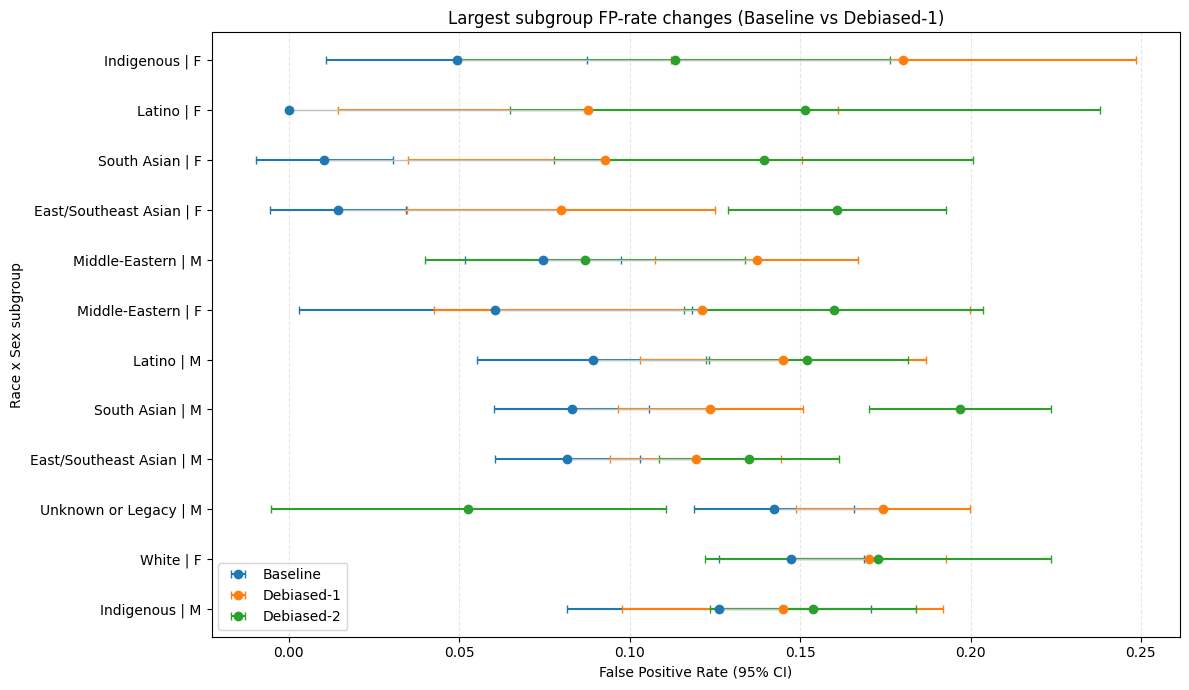

In [118]:
#Largest subgroup FP-rate changes with confidence intervals (Baseline vs Debiased-1 vs Debiased-2)
def _subgroup_fp_stats(y_true, y_pred, subgroup_series):
    df = pd.DataFrame({
        'group': subgroup_series.astype(str),
        'y_true': y_true.astype(int),
        'y_pred': pd.Series(y_pred).astype(int),
    })
    rows = []
    for group, part in df.groupby('group'):
        yt = part['y_true'].to_numpy()
        yp = part['y_pred'].to_numpy()
        fp = int(((yt == 0) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        n_neg = fp + tn
        fpr = (fp / n_neg) if n_neg else np.nan
        se = np.sqrt(fpr * (1 - fpr) / n_neg) if n_neg and np.isfinite(fpr) else 0.0
        ci = 1.96 * se
        rows.append({
            'group': group,
            'fp': fp,
            'tn': tn,
            'n_neg': n_neg,
            'fpr': fpr,
            'fpr_ci': ci,
        })
    return pd.DataFrame(rows)

base_stats = _subgroup_fp_stats(y_true_detail, results['Baseline']['y_pred'], X_eval_detail['Race_Sex_intersection'])
deb1_stats = _subgroup_fp_stats(y_true_detail, results['Debiased-1']['y_pred'], X_eval_detail['Race_Sex_intersection'])
deb2_stats = _subgroup_fp_stats(y_true_detail, results['Debiased-2']['y_pred'], X_eval_detail['Race_Sex_intersection'])

delta_df = base_stats.merge(deb1_stats, on='group', how='outer', suffixes=('_baseline', '_debiased_1'))
delta_df['delta_debiased_1'] = delta_df['fpr_debiased_1'] - delta_df['fpr_baseline']
delta_df = delta_df.sort_values(by='delta_debiased_1', key=lambda s: s.abs(), ascending=False).head(12)
delta_df = delta_df.sort_values('delta_debiased_1', ascending=True).reset_index(drop=True)

delta_df2 = base_stats.merge(deb2_stats, on='group', how='outer', suffixes=('_baseline', '_debiased_2'))
delta_df2['delta_debiased_2'] = delta_df2['fpr_debiased_2'] - delta_df2['fpr_baseline']
delta_df2 = delta_df2.sort_values(by='delta_debiased_2', key=lambda s: s.abs(), ascending=False).head(12)
delta_df2 = delta_df2.sort_values('delta_debiased_2', ascending=True).reset_index(drop=True)    

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(delta_df))
ax.errorbar(
    delta_df['fpr_baseline'],
    y_pos,
    xerr=delta_df['fpr_ci_baseline'],
    fmt='o',
    color='#1f77b4',
    capsize=3,
    label='Baseline',
)
ax.errorbar(
    delta_df['fpr_debiased_1'],
    y_pos,
    xerr=delta_df['fpr_ci_debiased_1'],
    fmt='o',
    color='#ff7f0e',
    capsize=3,
    label='Debiased-1',
)
ax.errorbar(
    delta_df2['fpr_debiased_2'],
    y_pos,
    xerr=delta_df2['fpr_ci_debiased_2'],
    fmt='o',
    color='#2ca02c',
    capsize=3,
    label='Debiased-2',
)
for i, row in enumerate(delta_df.itertuples(index=False)):
    ax.plot([row.fpr_baseline, row.fpr_debiased_1], [i, i], color='0.75', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(delta_df['group'])
ax.set_xlabel('False Positive Rate (95% CI)')
ax.set_ylabel('Race x Sex subgroup')
ax.set_title('Largest subgroup FP-rate changes (Baseline vs Debiased-1)')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()




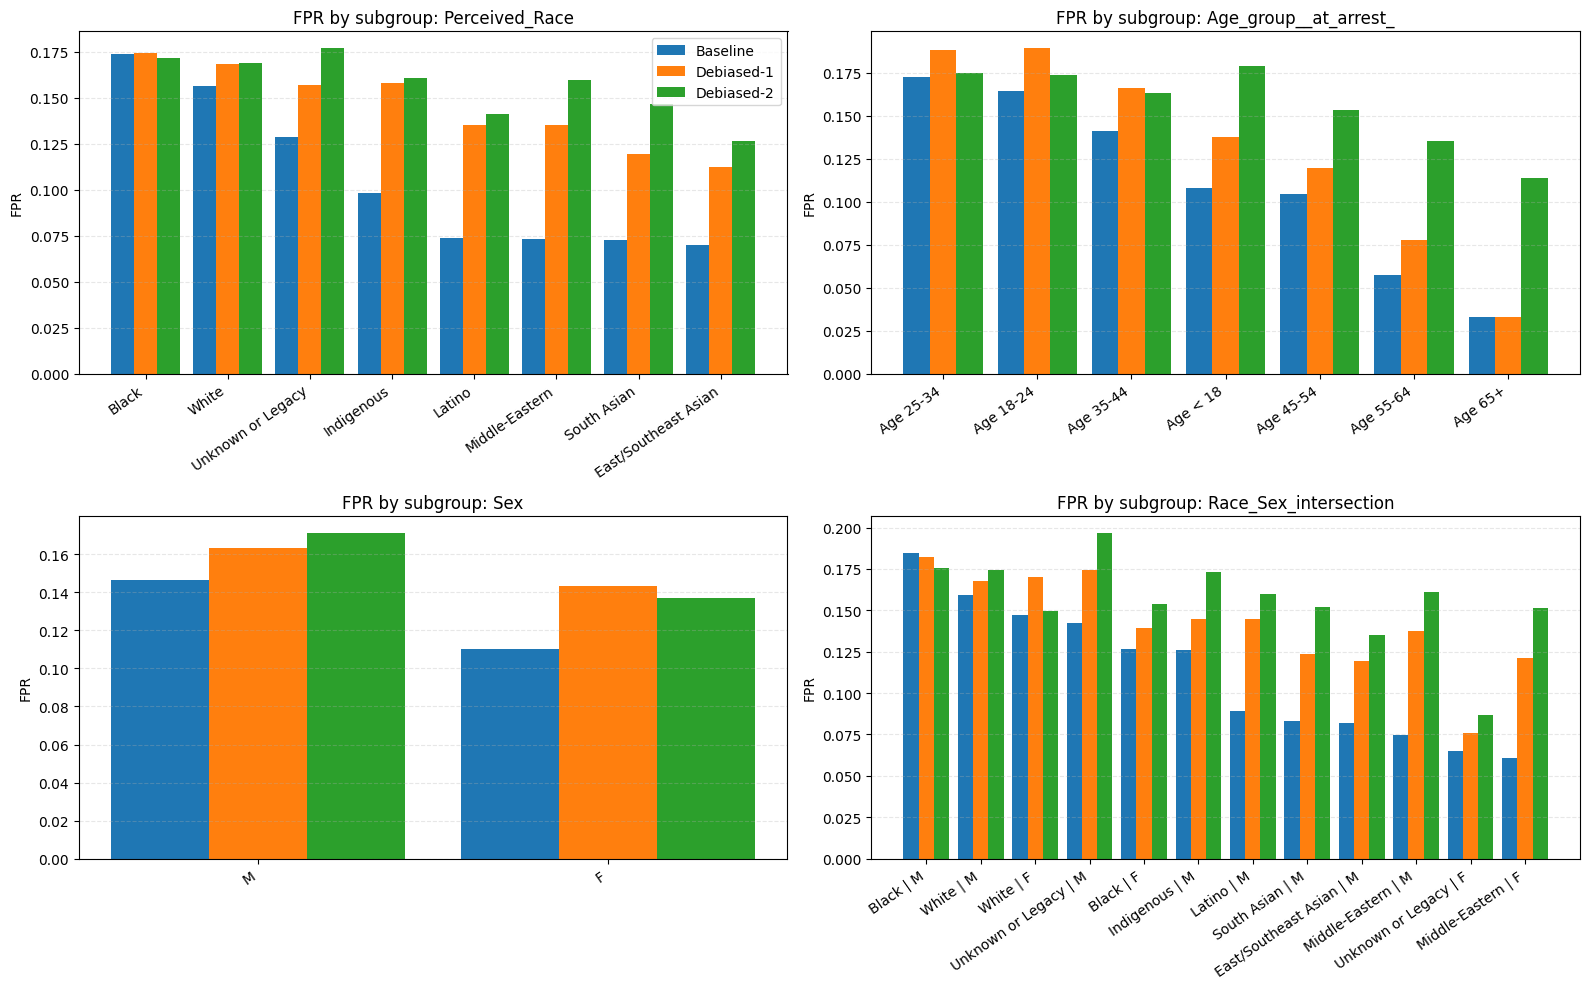

In [119]:
# subgroup FPR analysis for race, age, sex, and intersection
labels_age = {
    '0': 'Age < 18',
    '1': 'Age 18-24',
    '2': 'Age 25-34',
    '3': 'Age 35-44',
    '4': 'Age 45-54',
    '5': 'Age 55-64',
    '6': 'Age 65+',
}

for col in ['Age_group__at_arrest_']:
    X_eval_detail[col] = X_eval_detail[col].astype(str).map(labels_age).fillna(X_eval_detail[col])


def _group_metric_table(y_true, y_pred, group_series):
    df = pd.DataFrame({'group': group_series.astype(str), 'y_true': y_true.astype(int), 'y_pred': pd.Series(y_pred).astype(int)})
    rows = []
    for group, part in df.groupby('group'):
        yt = part['y_true'].to_numpy()
        yp = part['y_pred'].to_numpy()
        tp = int(((yt == 1) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        n = len(part)
        rows.append({
            'group': group,
            'count': n,
            'TPR': tp / (tp + fn) if (tp + fn) else np.nan,
            'FPR': fp / (fp + tn) if (fp + tn) else np.nan,
            'FNR': fn / (tp + fn) if (tp + fn) else np.nan,
            'SelectionRate': (tp + fp) / n if n else np.nan,
        })
    return pd.DataFrame(rows)

plot_attrs = [
    'Perceived_Race',
    'Age_group__at_arrest_',
    'Sex',
    'Race_Sex_intersection',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
for idx, attr in enumerate(plot_attrs):
    baseline_tbl = _group_metric_table(y_true_detail, results['Baseline']['y_pred'], X_eval_detail[attr])
    deb1_tbl = _group_metric_table(y_true_detail, results['Debiased-1']['y_pred'], X_eval_detail[attr])
    deb2_tbl = _group_metric_table(y_true_detail, results['Debiased-2']['y_pred'], X_eval_detail[attr])

    merged = baseline_tbl[['group', 'FPR']].rename(columns={'FPR': 'Baseline'})
    merged = merged.merge(deb1_tbl[['group', 'FPR']].rename(columns={'FPR': 'Debiased-1'}), on='group', how='outer')
    merged = merged.merge(deb2_tbl[['group', 'FPR']].rename(columns={'FPR': 'Debiased-2'}), on='group', how='outer')
    merged = merged.fillna(0.0).sort_values('Baseline', ascending=False)

    top_n = 12 if len(merged) > 12 else len(merged)
    merged = merged.head(top_n)

    x = np.arange(len(merged))
    width = 0.28
    ax = axes[idx]
    ax.bar(x - width, merged['Baseline'], width, label='Baseline', color='#1f77b4')
    ax.bar(x, merged['Debiased-1'], width, label='Debiased-1', color='#ff7f0e')
    ax.bar(x + width, merged['Debiased-2'], width, label='Debiased-2', color='#2ca02c')
    ax.set_title(f'FPR by subgroup: {attr}')
    ax.set_xticks(x)
    ax.set_xticklabels(merged['group'], rotation=35, ha='right')
    ax.set_ylabel('FPR')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [120]:
attr_metric_gap_df = pd.DataFrame(attr_metric_gap_rows)
print('Attribute-metric gap table')
display(attr_metric_gap_df.sort_values(['attribute', 'metric', 'case']).reset_index(drop=True))

fpr_attr_gap_df = attr_metric_gap_df[attr_metric_gap_df['metric'] == 'FPR'].copy()

def _print_fpr_gap_statements(case_name, gap_df):
    print(f"FPR gap statements for {case_name}:")
    for attr in ['Sex', 'Perceived_Race', 'Race_Sex_intersection', 'Age_group__at_arrest_']:
        attr_gap_df = gap_df[gap_df['attribute'] == attr]
        if attr_gap_df.empty:
            print(f"  - {attr}: no rows found")
            continue
        avg_gap = float(attr_gap_df['avg_gap'].iloc[0])
        max_gap = float(attr_gap_df['max_gap'].iloc[0])
        print(f"  - avg gap in avg FPR between all subgroups of {attr} for {case_name}: {avg_gap:.3f}")
        print(f"  - largest gap in avg FPR between all subgroups of {attr} for {case_name}: {max_gap:.3f}")

for case in ['Baseline', 'Debiased-1', 'Debiased-2']:
    case_gap_df = fpr_attr_gap_df[fpr_attr_gap_df['case'] == case]
    _print_fpr_gap_statements(case, case_gap_df)
    print('-' * 100)

Attribute-metric gap table


,attribute,metric,case,avg_gap,max_gap
0,Age_group__at_arrest_,FNR,Baseline,0.096195,0.252747
1,Age_group__at_arrest_,FNR,Debiased-1,0.070277,0.151230
2,Age_group__at_arrest_,FNR,Debiased-2,0.065239,0.147163
3,Age_group__at_arrest_,FPR,Baseline,0.063711,0.139615
4,Age_group__at_arrest_,FPR,Debiased-1,0.070166,0.156688
5,Age_group__at_arrest_,FPR,Debiased-2,0.028151,0.065581
6,Age_group__at_arrest_,SelectionRate,Baseline,0.089074,0.204334
7,Age_group__at_arrest_,SelectionRate,Debiased-1,0.094950,0.220304
8,Age_group__at_arrest_,SelectionRate,Debiased-2,0.048891,0.126145
9,Age_group__at_arrest_,TPR,Baseline,0.096195,0.252747


FPR gap statements for Baseline:
  - avg gap in avg FPR between all subgroups of Sex for Baseline: 0.036
  - largest gap in avg FPR between all subgroups of Sex for Baseline: 0.036
  - avg gap in avg FPR between all subgroups of Perceived_Race for Baseline: 0.048
  - largest gap in avg FPR between all subgroups of Perceived_Race for Baseline: 0.104
  - avg gap in avg FPR between all subgroups of Race_Sex_intersection for Baseline: 0.065
  - largest gap in avg FPR between all subgroups of Race_Sex_intersection for Baseline: 0.184
  - avg gap in avg FPR between all subgroups of Age_group__at_arrest_ for Baseline: 0.064
  - largest gap in avg FPR between all subgroups of Age_group__at_arrest_ for Baseline: 0.140
----------------------------------------------------------------------------------------------------
FPR gap statements for Debiased-1:
  - avg gap in avg FPR between all subgroups of Sex for Debiased-1: 0.020
  - largest gap in avg FPR between all subgroups of Sex for Debiased-1:

In [121]:
# Save artifacts
SEEDED_DIR = os.path.join(OUT_BASE_DIR, 'final_evaluation', 'seeded')
os.makedirs(SEEDED_DIR, exist_ok=True)
fp_outer_display.to_csv(os.path.join(SEEDED_DIR, 'fp_subgroup_rates_outer_join.csv'), index=False)
case_fairness_summary.to_csv(os.path.join(SEEDED_DIR, 'case_fairness_summary.csv'), index=False)
attr_metric_gap_df.to_csv(os.path.join(SEEDED_DIR, 'attribute_metric_case_gap_table.csv'), index=False)
print('Saved fairness artifacts to:', SEEDED_DIR)

Saved fairness artifacts to: nn_madb_outputs/final_evaluation/seeded


## DiCE ML + Recourse (Baseline, Debiased-1, Debiased-2)


In [ ]:
DICE_DIR = os.path.join('.', 'nn_madb_outputs', 'dice_cf_seeded_final')
os.makedirs(DICE_DIR, exist_ok=True)

RECOURSE_DIR = os.path.join(OUT_BASE_DIR, 'final_evaluation', 'recourse')
os.makedirs(RECOURSE_DIR, exist_ok=True)
FORCE_REGENERATE_CFS = True


In [123]:
max_cfs = 10
# Recourse is computed for adverse predictions (StripSearch=1) and flipped to opposite (0).
max_counterfactuals = 1000
target_class = 0 # want to find samples with this classifiaction to find counterfactual of opposite "desired" class
target_column = 'StripSearch'
features_perturb = [
    'ArrestLocDiv',
    'Actions_at_arrest___Concealed_i',
    'Actions_at_arrest___Combative__',
    'Actions_at_arrest___Resisted__d',
    'Actions_at_arrest___Mental_inst',
    'Actions_at_arrest___Assaulted_o',
    'Actions_at_arrest___Cooperative',
]

group_cols = ['Perceived_Race', 'Sex', 'Age_group__at_arrest_']

In [124]:
def _sanitize_filename(s):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s)).strip('_')


class NNCaseWrapper:
    def __init__(self, nn_model, preprocessor, scaler, feature_columns, device=DEVICE):
        self.nn_model = nn_model
        self.preprocessor = preprocessor
        self.scaler = scaler
        self.feature_columns = feature_columns
        self.device = device

    def _to_model_features(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(X, columns=self.feature_columns)
        X_df = X_df[self.feature_columns]
        X_enc = self.preprocessor.transform(X_df)
        if hasattr(X_enc, 'toarray'):
            X_enc = X_enc.toarray()
        X_scaled = self.scaler.transform(X_enc).astype(np.float32)
        return X_scaled

    def predict_proba(self, X):
        X_np = self._to_model_features(X)
        with torch.no_grad():
            xb = torch.tensor(X_np, dtype=torch.float32, device=self.device)
            output = self.nn_model(xb)
            if isinstance(output, tuple):
                output = output[0]
            probs = torch.sigmoid(output).cpu().numpy().reshape(-1, 1)
        return np.hstack([1.0 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def get_test_with_pred_class(X_test, y_pred, num_counterfactuals, target_class, target_column):
    df_predicted = pd.DataFrame(y_pred, columns=[target_column])
    df_test_pred = pd.concat([X_test.reset_index(drop=True), df_predicted.reset_index(drop=True)], axis=1)
    target_set = df_test_pred.loc[df_test_pred[target_column] == target_class].drop([target_column], axis=1)
    if num_counterfactuals is None:
        num_counterfactuals = target_set.shape[0]
    elif num_counterfactuals > target_set.shape[0]:
        num_counterfactuals = target_set.shape[0]
    return target_set.iloc[0:num_counterfactuals, :].reset_index(drop=True)


def produce_cfs(dataset, cf_method, features_to_perturb, max_cfs_per_sample, feature_columns):
    out = []
    for i in range(dataset.shape[0]):
        sample = dataset.iloc[[i]]
        try:
            dice_exp = cf_method.generate_counterfactuals(
                sample,
                total_CFs=max_cfs_per_sample,
                desired_class='opposite',
                features_to_vary=features_to_perturb,
                verbose=False,
            )
            cfs_df = dice_exp.cf_examples_list[0].final_cfs_df
            if cfs_df is None or len(cfs_df) == 0:
                out.append([])
                continue
            cfs_features = cfs_df.drop(columns=[target_column], errors='ignore')
            cfs_features = cfs_features.reindex(columns=feature_columns)
            out.append(cfs_features.to_numpy().tolist())
        except Exception:
            out.append([])
    return out


def gen_counterfactuals_for_seed_case(case, out_path):
    name = case[0]['name']
    y_pred = case[1][name]['y_pred']
    target_set = get_test_with_pred_class(X_test, y_pred, max_counterfactuals, target_class, target_column)

    nn_wrapper = NNCaseWrapper(
        nn_model=case[2],
        preprocessor=case[0]['preprocessor'],
        scaler=case[0]['scaler'],
        feature_columns=X_test.columns.tolist(),
        device=DEVICE,
    )

    y_for_dice = y_test.copy().reset_index(drop=True)
    y_for_dice.name = target_column

    d = dice_ml.Data(
        dataframe=pd.concat([X_test.reset_index(drop=True), y_for_dice], axis=1),
        continuous_features=[],
        outcome_name=target_column,
    )
    m = dice_ml.Model(model=nn_wrapper, backend='sklearn')
    exp = dice_ml.Dice(d, m, method='random')

    cfs_out = produce_cfs(target_set, exp, features_perturb, max_cfs, X_test.columns.tolist())
    target_set = target_set.copy()
    target_set['cfs_list'] = cfs_out
    target_set.to_csv(out_path, index=False)
    return out_path


In [ ]:
case_families = {
    'Baseline': baseline_seed_runs,
    'Debiased-1': debiased1_seed_runs,
    'Debiased-2': debiased2_seed_runs,
}

OUT_BASE_DIR = "nn_madb_outputs"  
CF_DIR = Path(OUT_BASE_DIR) / "dice_cf_seeded_final"

def _build_cf_paths(cf_dir: Path):
    if not cf_dir.exists():
        raise FileNotFoundError(f"Counterfactual folder not found: {cf_dir.resolve()}")

    pat = re.compile(r"^cfs_(baseline|debiased_1|debiased_2)_seed_(\d+)\.csv$")
    buckets = {"Baseline": {}, "Debiased-1": {}, "Debiased-2": {}}
    case_map = {"baseline": "Baseline", "debiased_1": "Debiased-1", "debiased_2": "Debiased-2"}

    for p in cf_dir.glob("cfs_*_seed_*.csv"):
        m = pat.match(p.name)
        if not m:
            continue
        case_key, seed_s = m.group(1), m.group(2)
        buckets[case_map[case_key]][int(seed_s)] = str(p)

    out = {} # Convert seed->path maps into sorted lists
    for case, seed_map in buckets.items():
        if not seed_map:
            out[case] = []
            continue
        out[case] = [seed_map[s] for s in sorted(seed_map.keys())]
    return out

cf_paths = _build_cf_paths(CF_DIR)

for case_label, runs in case_families.items():
    slug = _sanitize_filename(case_label.lower().replace('-', '_'))
    for seed_idx, run in enumerate(runs, start=1):
        out = os.path.join(DICE_DIR, f'cfs_{slug}_seed_{seed_idx}.csv')
        if FORCE_REGENERATE_CFS or (not os.path.isfile(out)):
            gen_counterfactuals_for_seed_case(run, out)
        cf_paths[case_label].append(out)

CF_PATHS_PKL = os.path.join(MODELS_DIR, 'seeded_cf_paths_baseline_debiased1_debiased2.pkl')
with open(CF_PATHS_PKL, 'wb') as f:
    pickle.dump(cf_paths, f)

print('Saved CF path index to:', CF_PATHS_PKL)
for case_label, paths in cf_paths.items():
    print(case_label, len(paths))

Total duration for counterfactual generations = 86m 56.9s

### Recourse Analysis


In [130]:
def _normalize_cfs_list(cfs_obj, n_features):
    if cfs_obj is None or (isinstance(cfs_obj, float) and np.isnan(cfs_obj)):
        return np.array([])
    if isinstance(cfs_obj, str):
        try:
            cfs_obj = ast.literal_eval(cfs_obj)
        except Exception:
            return np.array([])
    if not isinstance(cfs_obj, list) or len(cfs_obj) == 0:
        return np.array([])

    rows = []
    for r in cfs_obj:
        if not isinstance(r, (list, tuple)):
            continue
        rr = list(r)
        if len(rr) == n_features + 1:
            rr = rr[:-1]
        if len(rr) != n_features:
            continue
        rows.append(rr)

    if not rows:
        return np.array([])
    return np.array(rows, dtype=object)


def _get_feature_type(feature_name):
    if feature_name == 'ArrestLocDiv':
        return 'categorical'
    return 'ordinal'


def _get_feature_details(df, features_to_perturb):
    feature_details = {}
    for feature in features_to_perturb:
        feature_type = _get_feature_type(feature)
        if feature_type == 'ordinal':
            col_num = pd.to_numeric(df[feature], errors='coerce')
            feature_details[feature] = {
                'type': 'ordinal',
                'range_min': float(col_num.min()),
                'range_max': float(col_num.max()),
            }
        else:
            feature_details[feature] = {
                'type': 'categorical',
                'categ_values': sorted(df[feature].astype(str).unique().tolist()),
            }
    return feature_details


def _pairwise_gap_stats(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size < 2:
        return np.nan, np.nan
    diffs = [abs(a - b) for a, b in combinations(vals, 2)]
    return float(np.mean(diffs)), float(np.max(diffs))


def _compute_seed_recourse_metrics(cfs_path):
    df = pd.read_csv(cfs_path)
    n_features = len(df.columns) - 1
    df['cfs_list'] = df['cfs_list'].apply(lambda x: _normalize_cfs_list(x, n_features))

    details = _get_feature_details(X_test, features_perturb)
    cost_df = recourse_metrics.recourse_cost_df(df, details, label_sentiment_binary=0)
    avail_df = recourse_metrics.recourse_availability_df(df)
    choice_df = recourse_metrics.recourse_choice_df(df)

    metrics = {}
    metrics['cost_mean'] = float(cost_df['recourse_cost'].mean()) if len(cost_df) else np.nan
    metrics['availability_mean'] = float(avail_df['recourse_availability'].mean()) if len(avail_df) else np.nan
    metrics['choice_mean'] = float(choice_df['recourse_choice'].mean()) if len(choice_df) else np.nan

    # Compute subgroup gaps for each recourse metric over core attributes.
    recourse_metric_cols = {
        'cost': ('recourse_cost', cost_df),
        'availability': ('recourse_availability', avail_df),
        'choice': ('recourse_choice', choice_df),
    }
    attrs = ['Perceived_Race', 'Sex', 'Age_group__at_arrest_']

    for metric_name, (metric_col, metric_df) in recourse_metric_cols.items():
        avg_gaps = []
        max_gaps = []
        for attr in attrs:
            grouped = metric_df.groupby(attr)[metric_col].mean()
            avg_gap, max_gap = _pairwise_gap_stats(grouped.values)
            avg_gaps.append(avg_gap)
            max_gaps.append(max_gap)

        metrics[f'{metric_name}_avg_gap'] = float(np.nanmean(avg_gaps))
        metrics[f'{metric_name}_max_gap'] = float(np.nanmean(max_gaps))

    return metrics


In [135]:
recourse_seed_rows = []
for case_label, paths in cf_paths.items():
    for seed_idx, path in enumerate(paths, start=1):
        m = _compute_seed_recourse_metrics(path)
        recourse_seed_rows.append({'case': case_label, 'seed': seed_idx, **m})

recourse_seed_df = pd.DataFrame(recourse_seed_rows)

recourse_summary_df = recourse_seed_df.groupby('case', as_index=False).agg(
    recourse_cost=('cost_mean', 'mean'),
    recourse_availability=('availability_mean', 'mean'),
    recourse_choice=('choice_mean', 'mean'),
    recourse_cost_avg_gap=('cost_avg_gap', 'mean'),
    recourse_availability_avg_gap=('availability_avg_gap', 'mean'),
    recourse_choice_avg_gap=('choice_avg_gap', 'mean'),
)

rows = []
for case, part in recourse_seed_df.groupby('case'):
    rows.append({
        'metric': 'cost',
        'case': case,
        'avg_metric': part['cost_mean'].mean(),
        'avg_gap': part['cost_avg_gap'].mean(),
        'max_gap': part['cost_max_gap'].mean(),
    })
    rows.append({
        'metric': 'availability',
        'case': case,
        'avg_metric': part['availability_mean'].mean(),
        'avg_gap': part['availability_avg_gap'].mean(),
        'max_gap': part['availability_max_gap'].mean(),
    })
    rows.append({
        'metric': 'choice',
        'case': case,
        'avg_metric': part['choice_mean'].mean(),
        'avg_gap': part['choice_avg_gap'].mean(),
        'max_gap': part['choice_max_gap'].mean(),
    })
recourse_metric_gap_df = pd.DataFrame(rows)

recourse_seed_df.to_csv(os.path.join(RECOURSE_DIR, 'recourse_seed_metrics.csv'), index=False)
recourse_summary_df.to_csv(os.path.join(RECOURSE_DIR, 'recourse_summary.csv'), index=False)
recourse_metric_gap_df.to_csv(os.path.join(RECOURSE_DIR, 'recourse_metric_gap_summary.csv'), index=False)

choice_gap_ci = recourse_seed_df.groupby('case')['choice_avg_gap'].agg(['mean', 'std', 'count']).rename(columns={'mean': 'avg_gap_metric'})
choice_gap_ci['gap_sem'] = (choice_gap_ci['std'] / np.sqrt(choice_gap_ci['count'].clip(lower=1))).fillna(0.0)
choice_gap_ci.reset_index().to_csv(os.path.join(RECOURSE_DIR, 'recourse_choice_gap_ci.csv'), index=False)

Recourse metric summary


,metric,case,avg_metric,avg_gap,max_gap
1,availability,Baseline,0.779800,0.073969,0.164184
4,availability,Debiased-1,0.791200,0.095734,0.217520
7,availability,Debiased-2,0.858200,0.055961,0.113355
2,choice,Baseline,7.243200,0.898324,1.889961
5,choice,Debiased-1,7.175400,1.064641,2.447058
8,choice,Debiased-2,8.119000,0.615916,1.349909
0,cost,Baseline,0.900994,0.139782,0.300451
3,cost,Debiased-1,0.942961,0.100373,0.237544
6,cost,Debiased-2,0.883905,0.085316,0.198328


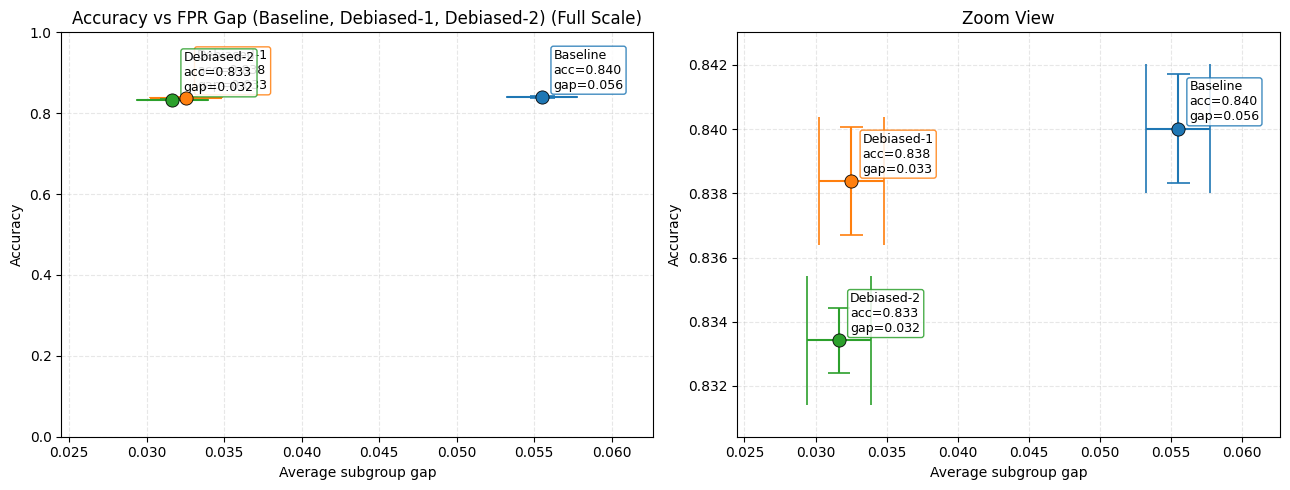

Saved plot: nn_madb_outputs/final_evaluation/recourse/accuracy_vs_fpr_gap_ci.png


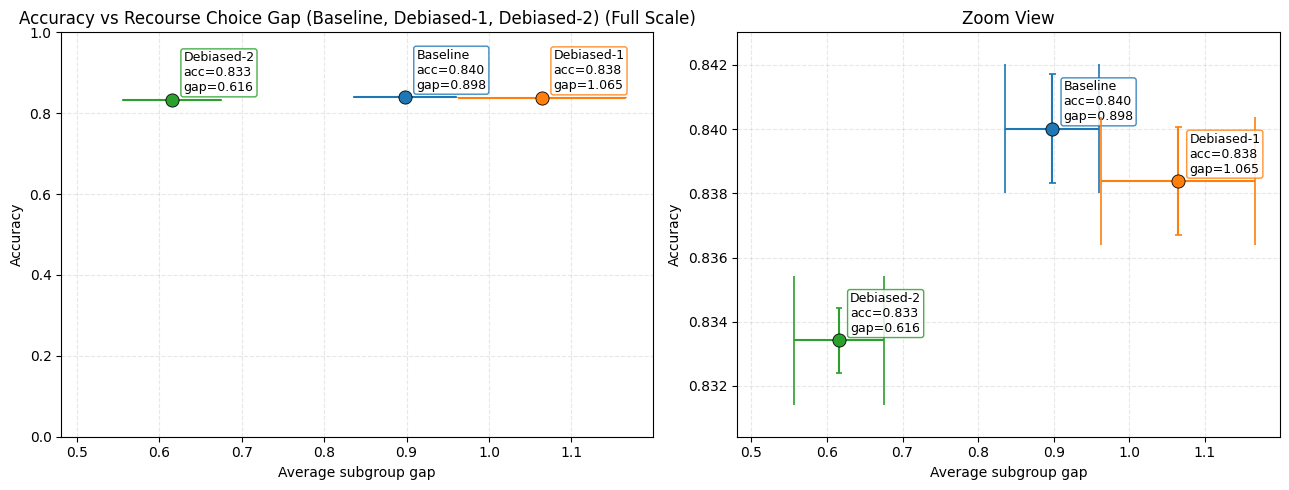

Saved plot: nn_madb_outputs/final_evaluation/recourse/accuracy_vs_recourse_choice_gap_ci.png


In [133]:
def plot_accuracy_vs_gap_with_ci(gap_ci_df, title, save_name, show_zoom=True):
    df = utility_summary_df.merge(
        gap_ci_df[['avg_gap_metric', 'gap_sem']],
        left_on='case',
        right_index=True,
        how='inner',
    ).merge(
        acc_sem_df[['accuracy_sem']],
        left_on='case',
        right_index=True,
        how='left',
    ).dropna(subset=['accuracy', 'avg_gap_metric'])

    order = ['Baseline', 'Debiased-1', 'Debiased-2']
    df = df[df['case'].isin(order)].copy()
    df['case_rank'] = df['case'].map({c: i for i, c in enumerate(order)})
    df = df.sort_values('case_rank').drop(columns='case_rank')

    colors = {'Baseline': '#1f77b4', 'Debiased-1': '#ff7f0e', 'Debiased-2': '#2ca02c'}

    if show_zoom:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.2, 1.1]})
        ax_full, ax_zoom = axes
    else:
        fig, ax_full = plt.subplots(figsize=(7, 5))
        ax_zoom = None

    def draw(ax):
        for _, row in df.iterrows():
            case = row['case']
            x = float(row['avg_gap_metric'])
            y = float(row['accuracy'])
            xerr = float(row.get('gap_sem', 0.0) or 0.0)
            yerr = float(row.get('accuracy_sem', 0.0) or 0.0)
            c = colors.get(case, '#444')

            ax.scatter([x], [y], s=90, color=c, edgecolor='black', linewidth=0.6, zorder=4)

            if np.isfinite(xerr) and xerr > 0:
                ax.hlines(y, x - xerr, x + xerr, colors=c, linewidth=1.5, zorder=3)
                ax.vlines([x - xerr, x + xerr], y - 0.002, y + 0.002, colors=c, linewidth=1.2, zorder=3)
            if np.isfinite(yerr) and yerr > 0:
                ax.vlines(x, y - yerr, y + yerr, colors=c, linewidth=1.5, zorder=3)
                capx = max((df['avg_gap_metric'].max() - df['avg_gap_metric'].min()) * 0.01, 0.0008)
                ax.hlines([y - yerr, y + yerr], x - capx, x + capx, colors=c, linewidth=1.2, zorder=3)

            ax.annotate(
                f"{case}\nacc={y:.3f}\ngap={x:.3f}",
                (x, y),
                textcoords='offset points',
                xytext=(8, 6),
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c, alpha=0.85),
            )

    draw(ax_full)
    x_min, x_max = df['avg_gap_metric'].min(), df['avg_gap_metric'].max()
    x_pad = max((x_max - x_min) * 0.30, 0.005)
    ax_full.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
    ax_full.set_ylim(0.0, 1.0)
    ax_full.set_xlabel('Average subgroup gap')
    ax_full.set_ylabel('Accuracy')
    ax_full.set_title(title + ' (Full Scale)')
    ax_full.grid(alpha=0.3, linestyle='--')

    if ax_zoom is not None:
        draw(ax_zoom)
        ax_zoom.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
        y_min, y_max = df['accuracy'].min(), df['accuracy'].max()
        y_pad = max((y_max - y_min) * 0.35, 0.003)
        ax_zoom.set_ylim(max(0, y_min - y_pad), min(1, y_max + y_pad))
        ax_zoom.set_xlabel('Average subgroup gap')
        ax_zoom.set_ylabel('Accuracy')
        ax_zoom.set_title('Zoom View')
        ax_zoom.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    out_path = os.path.join(RECOURSE_DIR, save_name)
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved plot:', out_path)


plot_accuracy_vs_gap_with_ci(
    fpr_gap_ci,
    'Accuracy vs FPR Gap (Baseline, Debiased-1, Debiased-2)',
    'accuracy_vs_fpr_gap_ci.png',
    show_zoom=True,
)

plot_accuracy_vs_gap_with_ci(
    choice_gap_ci,
    'Accuracy vs Recourse Choice Gap (Baseline, Debiased-1, Debiased-2)',
    'accuracy_vs_recourse_choice_gap_ci.png',
    show_zoom=True,
)